## NSF-RTG: Geometry-Aware Learning with Symmetric Positive Definite Matrices

Comparison of BW, AI, and LogE geometries for EEG motor imagery classification.

**Datasets:** BCI III IIIa · BCI III IVa · PhysioNet EEG Motor Imagery

## 1. Setup
### 1.1 Imports

In [ ]:
# !pip install umap-learn pyriemann
import numpy as np
import pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, cohen_kappa_score)
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.manifold import trustworthiness
from sklearn.base import clone, BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.metrics import pairwise_distances
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from scipy.stats import spearmanr
from scipy.spatial.distance import cdist
from IPython.display import display, HTML

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Data Loading

In [ ]:
# ── BCI III IIIa ──────────────────────────────────────────────
bci3a_train = np.load('/content/drive/MyDrive/RTG Summer 2026/BCI III IIIa/bci3_iiia_train_covariances.npz', allow_pickle=True)
bci3a_test  = np.load('/content/drive/MyDrive/RTG Summer 2026/BCI III IIIa/bci3_iiia_test_covariances.npz',  allow_pickle=True)

X_3a_train, y_3a_train = bci3a_train['X'], bci3a_train['y']
X_3a_test,  y_3a_test  = bci3a_test['X'],  bci3a_test['y']
subj_3a_train = bci3a_train['subject']

print("IIIa Train:", X_3a_train.shape, "| Classes:", np.unique(y_3a_train))
print("IIIa Test: ", X_3a_test.shape)
print("Tangent features (60x60):", 60*61//2, "→ 1830")

IIIa Train: (420, 60, 60) | Classes: [1 2 3 4]
IIIa Test:  (420, 60, 60)
Tangent features (60x60): 1830 → 1830


In [ ]:
# ── BCI III IVa ──────────────────────────────────────────────
bci4a_train = np.load('/content/drive/MyDrive/RTG Summer 2026/BCI III IVa/bci3_iva_train_covariances.npz', allow_pickle=True)
bci4a_test  = np.load('/content/drive/MyDrive/RTG Summer 2026/BCI III IVa/bci3_iva_test_covariances.npz',  allow_pickle=True)

X_4a_train_full, y_4a_train = bci4a_train['X'], bci4a_train['y']
X_4a_test_full,  y_4a_test  = bci4a_test['X'],  bci4a_test['y']
subj_4a_train = bci4a_train['subject']

# 20x20 subset (Michael's recommendation for testing)
X_4a_train_20 = X_4a_train_full[:, :20, :20]   # (560, 20, 20)
X_4a_test_20  = X_4a_test_full[:,  :20, :20]   # (840, 20, 20)

# Small subset for Task 1 (1 subject)
sub_idx    = (subj_4a_train == "aa")
X_small_4a = X_4a_train_full[sub_idx, :20, :20]
y_small_4a = y_4a_train[sub_idx]

print("IVa Train (20x20):", X_4a_train_20.shape, "| Classes:", np.unique(y_4a_train))
print("IVa Test  (20x20):", X_4a_test_20.shape)
print("Tangent features (20x20):", 20*21//2, "→ 210")

IVa Train (20x20): (560, 20, 20) | Classes: [1 2]
IVa Test  (20x20): (840, 20, 20)
Tangent features (20x20): 210 → 210


In [ ]:
# ── PhysioNet ──────────────────────────────────────────────────
try:
    phys = np.load(
        '/content/drive/MyDrive/RTG Summer 2026/PhysioNet/physionet_task2_mi_left_right.npz',
        allow_pickle=True)
    X_phys        = phys['X']
    y_phys        = phys['y']
    subject_physio = phys['subject']
    print("PhysioNet X shape:", X_phys.shape)
    print("PhysioNet y unique:", np.unique(y_phys, return_counts=True))
    print("Tangent features (64x64):", 64*65//2, "→ 2080")
except Exception as e:
    print("PhysioNet load failed:", e)
    X_phys, y_phys, subject_physio = None, None, None

In [ ]:
# ── Balanced PhysioNet subset: 250 per class ─────────────────
if X_phys is not None:
    idx_0 = np.where(y_phys == 0)[0][:250]   # 250 left-fist
    idx_1 = np.where(y_phys == 1)[0][:250]   # 250 right-fist
    balanced_idx = np.concatenate([idx_0, idx_1])
    rng = np.random.default_rng(42)
    rng.shuffle(balanced_idx)
    X_phys_small = X_phys[balanced_idx]
    y_phys_small = y_phys[balanced_idx]
    print("Balanced subset:", X_phys_small.shape)
    print("Class breakdown:", np.bincount(y_phys_small.astype(int)))
    # Should print: [250 250]

### 1.3 Metric Functions

In [ ]:
"""
Paste your metric_functions.py content here.
Functions needed:
  stack_npp_to_ppn
  compute_mean_projection
  project_stack_to_tangent_features
  compute_pairwise_distance_matrix
"""

"""
Helper functions for working with symmetric positive definite (SPD) matrices.

The main geometries included are:

1. Bures--Wasserstein (BW)
2. Affine-Invariant (AI)
3. Log-Euclidean (LogE)

Workflows will use these functions in three ways:

- Compute a distance between two SPD matrices.
- Compute a mean/reference SPD matrix for tangent-space projection.
- Compute a pairwise distance matrix for manifold UMAP with metric="precomputed".

Expected matrix formats
-----------------------
Individual SPD matrix:
    A.shape == (p, p)

Stack of SPD matrices in this file's mean functions:
    X.shape == (p, p, n)

However, many datasets are stored as:
    X.shape == (n, p, p)

If your data are stored as (n, p, p), convert them by using:
    X_ppn = np.moveaxis(X, 0, 2)

or use the helper:
    X_ppn = stack_npp_to_ppn(X)
"""

from __future__ import annotations

import numpy as np
from scipy.linalg import sqrtm, logm, expm


# ============================================================
# Utilities
# ============================================================
# These are small numerical helper functions.
# SPD computations are sensitive to small numerical asymmetries and tiny
# negative eigenvalues caused by floating-point error. These utilities make the
# matrices safer to use before taking square roots, inverse square roots, logs,
# or exponentials.


def sym(A: np.ndarray) -> np.ndarray:
    """
    Return the symmetric part of a square matrix.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        A square matrix that should be symmetric, up to numerical error.

    Returns
    -------
    ndarray, shape (p, p)
        The matrix (A + A.T) / 2.
    """
    return 0.5 * (A + A.T)



def make_spd(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Symmetrize a matrix and floor its eigenvalues to make it SPD.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        Input square matrix.
    eps : float, default=1e-12
        Minimum eigenvalue allowed. If eps <= 0, only symmetrization is done.

    Returns
    -------
    ndarray, shape (p, p)
        A symmetric positive definite matrix.
    """
    A = sym(A)
    if eps <= 0:
        return A

    w, V = np.linalg.eigh(A)
    w = np.maximum(w, eps)
    return (V * w) @ V.T



def sqrtm_spd(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute the symmetric matrix square root of an SPD matrix.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        SPD matrix.
    eps : float, default=1e-12
        Eigenvalue floor for numerical stability.

    Returns
    -------
    ndarray, shape (p, p)
        The matrix square root A^{1/2}.
    """
    A = make_spd(A, eps=eps)
    w, V = np.linalg.eigh(A)
    if eps > 0:
        w = np.maximum(w, eps)
    return (V * np.sqrt(w)) @ V.T



def invsqrtm_spd(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute the symmetric inverse square root of an SPD matrix.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        SPD matrix.
    eps : float, default=1e-12
        Eigenvalue floor for numerical stability.

    Returns
    -------
    ndarray, shape (p, p)
        The inverse square root A^{-1/2}.
    """
    A = make_spd(A, eps=eps)
    w, V = np.linalg.eigh(A)
    if eps > 0:
        w = np.maximum(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T



def logm_spd(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute the matrix logarithm of an SPD matrix using eigen-decomposition.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        SPD matrix.
    eps : float, default=1e-12
        Eigenvalue floor for numerical stability.

    Returns
    -------
    ndarray, shape (p, p)
        The symmetric matrix logarithm log(A).
    """
    A = make_spd(A, eps=eps)
    w, V = np.linalg.eigh(A)
    if eps > 0:
        w = np.maximum(w, eps)
    return (V * np.log(w)) @ V.T



def expm_sym(A: np.ndarray) -> np.ndarray:
    """
    Compute the matrix exponential of a symmetric matrix.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        Symmetric matrix, usually a tangent vector.

    Returns
    -------
    ndarray, shape (p, p)
        The SPD matrix exp(A).
    """
    A = sym(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T



def stack_npp_to_ppn(X: np.ndarray) -> np.ndarray:
    """
    Convert a stack from shape (n, p, p) to shape (p, p, n).

    Parameters
    ----------
    X : ndarray, shape (n, p, p)
        Dataset format commonly used in machine learning.

    Returns
    -------
    ndarray, shape (p, p, n)
        Dataset format expected by the mean routines in this file.
    """
    if X.ndim != 3:
        raise ValueError(f"Expected X with 3 dimensions, got shape {X.shape}")
    if X.shape[1] != X.shape[2]:
        raise ValueError(f"Expected X with shape (n,p,p), got shape {X.shape}")
    return np.moveaxis(X, 0, 2)



def stack_ppn_to_npp(X: np.ndarray) -> np.ndarray:
    """
    Convert a stack from shape (p, p, n) to shape (n, p, p).
    """
    if X.ndim != 3:
        raise ValueError(f"Expected X with 3 dimensions, got shape {X.shape}")
    if X.shape[0] != X.shape[1]:
        raise ValueError(f"Expected X with shape (p,p,n), got shape {X.shape}")
    return np.moveaxis(X, 2, 0)


# ============================================================
# BW (Bures--Wasserstein)
# ============================================================

def BW_log(X: np.ndarray, Y: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Parameters
    ----------
    X : ndarray, shape (p, p)
        Current reference SPD matrix.
    Y : ndarray, shape (p, p)
        Target SPD matrix.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (p, p)
        A symmetric matrix used as a tangent-like update in the iterative BW
        mean calculation.
    """
    X = make_spd(X, eps=eps)
    Y = make_spd(Y, eps=eps)

    S = sqrtm_spd(X @ Y, eps=eps)
    return sym(S + S.T - 2.0 * X)



def BW_exp(A: np.ndarray, V: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Parameters
    ----------
    A : ndarray, shape (p, p)
        Current reference SPD matrix.
    V : ndarray, shape (p, p)
        Symmetric update direction.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (p, p)
        Updated SPD matrix.
    """
    A = make_spd(A, eps=eps)
    V = sym(V)

    lam, U = np.linalg.eigh(A)
    if eps > 0:
        lam = np.maximum(lam, eps)

    Vu = U.T @ V @ U

    lam_i = lam[:, None]
    lam_j = lam[None, :]
    W = 1.0 / (lam_i + lam_j)

    C = (W * Vu) @ np.diag(lam) @ (W * Vu)
    out = A + V + U @ C @ U.T
    return make_spd(out, eps=eps)



def compute_BW_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-12) -> float:
    """
    Compute the Bures--Wasserstein distance between two SPD matrices.

    Parameters
    ----------
    X, Y : ndarray, shape (p, p)
        SPD matrices.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    float
        BW distance between X and Y.
    """
    X = make_spd(X, eps=eps)
    Y = make_spd(Y, eps=eps)

    Xh = sqrtm_spd(X, eps=eps)
    mid = Xh @ Y @ Xh
    mid_sqrt = sqrtm_spd(mid, eps=eps)

    d2 = np.trace(X) + np.trace(Y) - 2.0 * np.trace(mid_sqrt)
    d2 = float(np.maximum(d2, 0.0))
    return float(np.sqrt(d2))


# ============================================================
# AI (Affine-Invariant)
# ============================================================

def compute_AI_distance(A: np.ndarray, B: np.ndarray, eps: float | None = None) -> float:
    """
    Compute the Affine-Invariant distance between two SPD matrices.

    Parameters
    ----------
    A, B : ndarray, shape (p, p)
        SPD matrices.
    eps : float or None
        Accepted for compatibility with other functions. This implementation
        does not use eps directly.

    Returns
    -------
    float
        Affine-Invariant Riemannian distance.
    """
    temp = np.dot(np.linalg.inv(A), B)
    lambdas, _ = np.linalg.eig(temp)

    # np.real handles tiny imaginary parts caused by floating-point error.
    out = np.real(np.sqrt(np.sum(np.log(np.real(lambdas)) ** 2) + 0j))
    return float(out)



def AI_log(A: np.ndarray, B: np.ndarray, eps: float | None = None) -> np.ndarray:
    """
    Compute the Affine-Invariant logarithm map of B at base point A.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        Base/reference SPD matrix.
    B : ndarray, shape (p, p)
        Target SPD matrix.
    eps : float or None
        Accepted for compatibility. This SciPy version does not use eps.

    Returns
    -------
    ndarray, shape (p, p)
        Tangent vector at A pointing toward B.
    """
    Ainv_sqrt = sqrtm(np.linalg.inv(A))
    temp = logm(Ainv_sqrt.dot(B).dot(Ainv_sqrt))
    out = sqrtm(A).dot(temp).dot(sqrtm(A))
    return np.real(sym(out))



def AI_exp(A: np.ndarray, B: np.ndarray, eps: float | None = None) -> np.ndarray:
    """
    Compute the Affine-Invariant exponential map at base point A.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        Base/reference SPD matrix.
    B : ndarray, shape (p, p)
        Tangent vector at A.
    eps : float or None
        Accepted for compatibility. This SciPy version does not use eps.

    Returns
    -------
    ndarray, shape (p, p)
        SPD matrix reached by moving from A in tangent direction B.
    """
    Ainv_sqrt = sqrtm(np.linalg.inv(A))
    temp = expm(Ainv_sqrt.dot(B).dot(Ainv_sqrt))
    out = sqrtm(A).dot(temp).dot(sqrtm(A))
    return make_spd(np.real(sym(out)), eps=1e-12)


# ============================================================
# Log-Euclidean (LogE)
# ============================================================

def LogE_mean(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Parameters
    ----------
    X : ndarray, shape (p, p, n)
        SPD matrices stacked along the third axis.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (p, p)
        Log-Euclidean mean.

    Project use
    -----------
    Use this to compute the reference matrix for LogE tangent projection.
    """
    n = X.shape[2]
    acc = np.zeros((X.shape[0], X.shape[1]), dtype=X.dtype)
    for i in range(n):
        acc += logm_spd(X[:, :, i], eps=eps)
    acc /= float(n)
    return make_spd(expm_sym(acc), eps=eps)



def LogE_log(M: np.ndarray, C: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute the Log-Euclidean log map of C at reference matrix M.

    Parameters
    ----------
    M : ndarray, shape (p, p)
        Reference SPD matrix, usually the LogE mean.
    C : ndarray, shape (p, p)
        SPD matrix to project.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (p, p)
        Tangent vector log(C) - log(M).
    """
    M = make_spd(M, eps=eps)
    C = make_spd(C, eps=eps)
    return sym(logm_spd(C, eps=eps) - logm_spd(M, eps=eps))



def LogE_exp(M: np.ndarray, V: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute the Log-Euclidean exponential map at reference matrix M.

    Parameters
    ----------
    M : ndarray, shape (p, p)
        Reference SPD matrix.
    V : ndarray, shape (p, p)
        Tangent vector.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (p, p)
        SPD matrix exp(log(M) + V).
    """
    M = make_spd(M, eps=eps)
    V = sym(V)
    return make_spd(expm_sym(logm_spd(M, eps=eps) + V), eps=eps)



def LogE_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-12) -> float:
    """
    Compute the Log-Euclidean distance between two SPD matrices.

    Parameters
    ----------
    X, Y : ndarray, shape (p, p)
        SPD matrices.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    float
        Frobenius norm of log(X) - log(Y).
    """
    X = make_spd(X, eps=eps)
    Y = make_spd(Y, eps=eps)
    return float(np.linalg.norm(logm_spd(X, eps=eps) - logm_spd(Y, eps=eps), ord="fro"))


# ============================================================
# Backward compatibility of older function names
# ============================================================
# These aliases let older code use BW_dist() and AI_dist().


def BW_dist(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> float:
    """Alias for compute_BW_distance()."""
    return compute_BW_distance(A, B, eps=eps)



def AI_dist(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> float:
    """Alias for compute_AI_distance()."""
    return compute_AI_distance(A, B, eps=eps)


# ============================================================
# Barycenter for tangent-space projection
# ============================================================
# These functions compute the reference point/mean on the SPD manifold. For
# statistically correct cross-validation, compute the mean using the training
# fold only, then project both train and test matrices using that training mean.


def bw_projection_mean(
    X: np.ndarray,
    tol: float,
    verbose: bool = False,
    spd_eps: float = 1e-12,
    max_iter: int = 500,
):
    """
    Compute an iterative Bures--Wasserstein mean.

    Parameters
    ----------
    X : ndarray, shape (p, p, n)
        SPD matrices stacked on the third axis.
    tol : float
        Stop when the change between successive means is below this value.
    verbose : bool, default=False
        If True, print the convergence trace.
    spd_eps : float, default=1e-12
        Numerical eigenvalue floor.
    max_iter : int, default=500
        Maximum number of iterations.

    Returns
    -------
    mean : ndarray, shape (p, p)
        Estimated BW mean.
    iters : int
        Number of iterations used.
    final_dist : float
        Final distance between successive mean estimates.
    """
    if X.ndim != 3:
        raise ValueError(f"Expected X with shape (p,p,n), got {X.shape}")

    p, p2, n = X.shape
    if p != p2:
        raise ValueError(f"Expected square matrices, got {X.shape}")

    mean_new = np.mean(X, axis=2)
    dist_mean = float("inf")
    k = 0

    while dist_mean > tol and k < max_iter:
        U, s, VT = np.linalg.svd(mean_new, full_matrices=True)
        mean_old = VT.T @ np.diag(s) @ VT
        mean_old = sym(mean_old)
        mean_old = make_spd(mean_old, eps=spd_eps)

        acc = np.zeros((p, p), dtype=X.dtype)
        for i in range(n):
            acc += BW_log(mean_old, X[:, :, i], eps=spd_eps)
        mean_tangent = acc / float(n)

        mean_new = np.real(BW_exp(mean_old, mean_tangent, eps=spd_eps))
        mean_new = make_spd(mean_new, eps=spd_eps)

        dist_mean = BW_dist(mean_new, mean_old, eps=spd_eps)

        k += 1
        if verbose:
            print(f"Iter{k}, dist_mean={dist_mean:.7f}")

    return mean_new, k, float(dist_mean)



def ai_projection_mean(
    X: np.ndarray,
    tol: float,
    verbose: bool = False,
    spd_eps: float = 1e-12,
    max_iter: int = 500,
):
    """
    Compute an iterative Affine-Invariant mean.

    Parameters
    ----------
    X : ndarray, shape (p, p, n)
        SPD matrices stacked on the third axis.
    tol : float
        Convergence tolerance.
    verbose : bool, default=False
        If True, print the convergence trace.
    spd_eps : float, default=1e-12
        Numerical eigenvalue floor.
    max_iter : int, default=500
        Maximum number of iterations.

    Returns
    -------
    mean : ndarray, shape (p, p)
        Estimated AI mean.
    iters : int
        Number of iterations used.
    final_dist : float
        Final step distance.
    """
    if X.ndim != 3:
        raise ValueError(f"Expected X with shape (p,p,n), got {X.shape}")

    p, p2, n = X.shape
    if p != p2:
        raise ValueError(f"Expected square matrices, got {X.shape}")

    mean_new = np.mean(X, axis=2)
    dist_mean = float("inf")
    smaller_step = True
    k = 0
    last_dist = None

    mean_old = make_spd(sym(mean_new), eps=spd_eps)

    while dist_mean > tol and smaller_step and k < max_iter:
        U, s, VT = np.linalg.svd(mean_new, full_matrices=True)
        mean_old_candidate = VT.T @ np.diag(s) @ VT
        mean_old_candidate = sym(mean_old_candidate)
        mean_old_candidate = make_spd(mean_old_candidate, eps=spd_eps)

        acc = np.zeros((p, p), dtype=X.dtype)
        for i in range(n):
            acc += AI_log(mean_old_candidate, X[:, :, i], eps=spd_eps)
        mean_tangent = acc / float(n)

        mean_new_candidate = np.real(AI_exp(mean_old_candidate, mean_tangent, eps=spd_eps))
        mean_new_candidate = make_spd(mean_new_candidate, eps=spd_eps)

        dist_mean = AI_dist(mean_new_candidate, mean_old_candidate, eps=spd_eps)

        if k == 0:
            smaller_step = True
        else:
            smaller_step = (last_dist - dist_mean) > 1e-4

        if verbose:
            ss = "NA" if k == 0 else str(smaller_step)
            print(f"Iter{k}, Smaller step? {ss}, dist_mean={dist_mean:.7f}")

        if smaller_step:
            mean_old = mean_new_candidate
            mean_new = mean_new_candidate

        k += 1
        last_dist = dist_mean

    return mean_old, k, float(dist_mean)



def compute_mean_projection(
    X: np.ndarray,
    metric: str,
    tol: float = 1e-6,
    spd_eps: float = 1e-12,
    max_iter: int = 500,
    verbose: bool = False,
):
    """
    Convenience wrapper to compute the mean/reference SPD matrix for one metric.

    Parameters
    ----------
    X : ndarray, shape (p, p, n)
        SPD matrices stacked on the third axis.
    metric : {'bw', 'ai', 'loge'}
        Geometry used for the mean.
    tol : float, default=1e-6
        Convergence tolerance for BW and AI.
    spd_eps : float, default=1e-12
        Numerical eigenvalue floor.
    max_iter : int, default=500
        Maximum iterations for BW and AI.
    verbose : bool, default=False
        If True, print convergence information.

    Returns
    -------
    mean : ndarray, shape (p, p)
        Mean/reference SPD matrix.
    info : dict
        Small dictionary with convergence information.

    Project use
    -----------
    This gives students one function to call regardless of metric.
    """
    metric = metric.lower()
    if metric in {"bw", "bures", "bures-wasserstein", "bures_wasserstein"}:
        M, iters, final = bw_projection_mean(
            X, tol=tol, verbose=verbose, spd_eps=spd_eps, max_iter=max_iter
        )
        return M, {"metric": "bw", "iters": iters, "final": final}

    if metric in {"ai", "airm", "affine", "affine-invariant", "affine_invariant"}:
        M, iters, final = ai_projection_mean(
            X, tol=tol, max_iter=max_iter, verbose=verbose
        )
        return M, {"metric": "ai", "iters": iters, "final": final}

    if metric in {"loge", "log-euclidean", "log_euclidean"}:
        M = LogE_mean(X, eps=spd_eps)
        return M, {"metric": "loge", "iters": 0, "final": 0.0}

    raise ValueError("metric must be one of: 'bw', 'ai', or 'loge'")


# ============================================================
# Tangent projection helpers
# ============================================================

def project_to_tangent(M: np.ndarray, C: np.ndarray, metric: str, eps: float = 1e-12) -> np.ndarray:
    """
    Project one SPD matrix C to the tangent space at reference matrix M.

    Parameters
    ----------
    M : ndarray, shape (p, p)
        Reference/mean SPD matrix.
    C : ndarray, shape (p, p)
        SPD matrix to project.
    metric : {'bw', 'ai', 'loge'}
        Geometry used for the projection.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (p, p)
        Symmetric tangent matrix.
    """
    metric = metric.lower()
    if metric in {"bw", "bures", "bures-wasserstein", "bures_wasserstein"}:
        return BW_log(M, C, eps=eps)
    if metric in {"ai", "airm", "affine", "affine-invariant", "affine_invariant"}:
        return AI_log(M, C, eps=eps)
    if metric in {"loge", "log-euclidean", "log_euclidean"}:
        return LogE_log(M, C, eps=eps)
    raise ValueError("metric must be one of: 'bw', 'ai', or 'loge'")



def vectorize_symmetric(A: np.ndarray) -> np.ndarray:
    """
    Vectorize the upper triangle of a symmetric matrix.

    Parameters
    ----------
    A : ndarray, shape (p, p)
        Symmetric matrix.

    Returns
    -------
    ndarray, shape (p * (p + 1) / 2,)
        Vectorized upper triangle.
    """
    A = sym(A)
    p = A.shape[0]
    idx = np.triu_indices(p)
    v = A[idx].copy()
    return v



def project_stack_to_tangent_features(
    X: np.ndarray,
    M: np.ndarray,
    metric: str,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Project a stack of SPD matrices to vectorized tangent features.

    Parameters
    ----------
    X : ndarray, shape (n, p, p) or (p, p, n)
        Stack of SPD matrices.
    M : ndarray, shape (p, p)
        Reference/mean SPD matrix.
    metric : {'bw', 'ai', 'loge'}
        Geometry used for tangent projection.
    eps : float, default=1e-12
        Numerical eigenvalue floor.

    Returns
    -------
    ndarray, shape (n, p * (p + 1) / 2)
        Tangent feature matrix for scikit-learn.
    """
    if X.ndim != 3:
        raise ValueError(f"Expected a 3D stack, got shape {X.shape}")

    # Accept either common storage convention.
    if X.shape[1] == X.shape[2]:
        X_npp = X
    elif X.shape[0] == X.shape[1]:
        X_npp = stack_ppn_to_npp(X)
    else:
        raise ValueError(f"Could not identify matrix stack format from shape {X.shape}")

    features = []
    for C in X_npp:
        T = project_to_tangent(M, C, metric=metric, eps=eps)
        features.append(vectorize_symmetric(T))

    return np.vstack(features)


# ============================================================
# Pairwise distance matrix for manifold UMAP
# ============================================================
# Manifold UMAP with metric='precomputed' needs an n x n distance matrix. This
# function computes that matrix using AI, LogE, or BW distances directly on the
# SPD matrices.


def compute_pairwise_distance_matrix(
    X: np.ndarray,
    metric: str = "bw",
    eps: float = 1e-12,
    verbose: bool = True,
) -> np.ndarray:
    """
    Compute an n x n pairwise distance matrix for a stack of SPD matrices.

    Parameters
    ----------
    X : ndarray, shape (n, p, p) or (p, p, n)
        Stack of SPD matrices.
    metric : {'bw', 'ai', 'loge'}, default='bw'
        Distance metric to use.
    eps : float, default=1e-12
        Numerical eigenvalue floor.
    verbose : bool, default=True
        If True, print occasional progress updates.

    Returns
    -------
    D : ndarray, shape (n, n)
        Symmetric pairwise distance matrix with zeros on the diagonal.

    Notes
    -----
    This is O(n^2) in the number of matrices, so start with a smaller subset
    while debugging.
    """
    if X.ndim != 3:
        raise ValueError(f"Expected a 3D stack, got shape {X.shape}")

    if X.shape[1] == X.shape[2]:
        X_npp = X
    elif X.shape[0] == X.shape[1]:
        X_npp = stack_ppn_to_npp(X)
    else:
        raise ValueError(f"Could not identify matrix stack format from shape {X.shape}")

    metric = metric.lower()
    if metric in {"bw", "bures", "bures-wasserstein", "bures_wasserstein"}:
        dist_fun = lambda A, B: compute_BW_distance(A, B, eps=eps)
    elif metric in {"ai", "airm", "affine", "affine-invariant", "affine_invariant"}:
        dist_fun = lambda A, B: compute_AI_distance(A, B, eps=eps)
    elif metric in {"loge", "log-euclidean", "log_euclidean"}:
        dist_fun = lambda A, B: LogE_distance(A, B, eps=eps)
    else:
        raise ValueError("metric must be one of: 'bw', 'ai', or 'loge'")

    n = X_npp.shape[0]
    D = np.zeros((n, n), dtype=float)

    total_pairs = n * (n - 1) // 2
    done = 0
    for i in range(n):
        for j in range(i + 1, n):
            d = dist_fun(X_npp[i], X_npp[j])
            D[i, j] = d
            D[j, i] = d
            done += 1

        if verbose and (i % 25 == 0 or i == n - 1):
            print(f"Computed distances for row {i + 1}/{n} ({done}/{total_pairs} pairs)")

    return D


### 1.4 UMAP Plot Helpers

In [ ]:
# ── Class label mappings ──────────────────────────────────────
CLASS_LABELS = {1: "Left Hand", 2: "Right Hand", 3: "Foot", 4: "Tongue"}
CLASS_COLORS = {1: "#2196F3", 2: "#F44336", 3: "#4CAF50", 4: "#FF9800"}

PHYS_LABELS = {0: "Left Fist", 1: "Right Fist"}
PHYS_COLORS = {0: "#2196F3",  1: "#F44336"}

IVA_LABELS  = {1: "Right Hand", 2: "Foot"}
IVA_COLORS  = {1: "#2196F3",   2: "#F44336"}

def plot_umap_classified(embedding, labels, title, ax=None, label_map=None, color_map=None):
    """Scatter plot with per-class colors and legend."""
    if label_map is None: label_map = CLASS_LABELS
    if color_map is None: color_map = CLASS_COLORS
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 5))
    for cls in sorted(label_map):
        mask = labels == cls
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   c=color_map[cls], label=label_map[cls],
                   s=10, alpha=0.7, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.legend(fontsize=8, markerscale=2)
    if standalone:
        plt.tight_layout()
        plt.show()

### 1.5 Classification Helper Functions

In [ ]:
class UMAPTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=10, metric='euclidean', random_state=None):
        self.n_components = n_components
        self.metric       = metric
        self.random_state = random_state
    def fit(self, X, y=None):
        self._umap = umap.UMAP(
            n_components=self.n_components,
            metric=self.metric,
            random_state=self.random_state)
        self._umap.fit(X)
        return self
    def transform(self, X):
        return self._umap.transform(X)

# Q values to compare — extend if time permits
Q_VALUES = [5, 10, 20, 50, 100, 200]
# If nested CV is too slow, reduce to: Q_VALUES = [5, 10, 20]

In [ ]:
class MedianHeuristicRBF(BaseEstimator, ClassifierMixin):
    """SVC with RBF kernel where gamma is set via the median heuristic."""
    def __init__(self, C=1.0, gamma_scale=1.0):
        self.C           = C
        self.gamma_scale = gamma_scale

    def fit(self, X, y):
        D      = pairwise_distances(X)
        d      = D[np.triu_indices_from(D, k=1)]
        d      = d[d > 0]
        med_sq = np.median(d ** 2)
        gamma  = self.gamma_scale / (2.0 * med_sq) if (med_sq > 0 and not np.isnan(med_sq)) else 'scale'
        self.gamma_ = gamma
        self.model_ = SVC(kernel='rbf', C=self.C, gamma=gamma,
                          probability=True, random_state=42)
        self.model_.fit(X, y)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):       return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)


base_classifiers_nested = {
    'LogReg':     LogisticRegression(max_iter=2000, solver='liblinear', random_state=42),
    'KNN':        KNeighborsClassifier(),
    'SVC_linear': SVC(kernel='linear', probability=True, random_state=42),
    'SVC_rbf':    MedianHeuristicRBF(),
}

# Reduce search space if nested CV is too slow
model_param_grids = {
    'LogReg':     {'clf__C': [0.01, 0.1, 1, 10, 100]},
    'KNN':        {'clf__n_neighbors': [3, 5, 7, 11, 15]},
    'SVC_linear': {'clf__C': [0.1, 1, 10]},
    'SVC_rbf':    {'clf__C': [0.1, 1, 10], 'clf__gamma_scale': [0.5, 1.0, 2.0]},
}

# Reduced search space (use if runtime is too long):
# model_param_grids = {
#     'LogReg':     {'clf__C': [0.1, 1, 10]},
#     'KNN':        {'clf__n_neighbors': [3, 7, 15]},
#     'SVC_linear': {'clf__C': [0.1, 1, 10]},
#     'SVC_rbf':    {'clf__C': [0.1, 1, 10], 'clf__gamma_scale': [0.5, 1.0, 2.0]},
# }

def clean_best_params(best_params):
    return {k.replace('clf__', ''): v for k, v in best_params.items()}

In [ ]:
def run_nested_cv(X_data, y_data, metric, n_outer=5, n_inner=3, random_state=42):
    """Nested CV for 4-class classification (BCI IIIa).
    Inner loop: GridSearchCV for hyperparameter tuning.
    Outer loop: StratifiedKFold for unbiased performance estimation.
    """
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=random_state)
    pipeline_configs = (
        [('A_full_raw', None, None, False), ('A_full_std', None, None, True)]
        + [('B_pca_raw_q{}'.format(q), 'pca',  q, False) for q in Q_VALUES]
        + [('B_pca_std_q{}'.format(q), 'pca',  q, True)  for q in Q_VALUES]
        + [('C_umap_raw_q{}'.format(q),'umap', q, False) for q in Q_VALUES]
        + [('C_umap_std_q{}'.format(q),'umap', q, True)  for q in Q_VALUES]
    )
    metric_keys = ['acc','precision','recall','auc','kappa','runtime','best_params']
    results = {pl[0]: {clf: {m: [] for m in metric_keys} for clf in base_classifiers_nested}
               for pl in pipeline_configs}
    print(f"\n{'='*60}\n  Nested CV | Geometry: {metric.upper()} | Dataset: BCI IIIa")
    print(f"  Outer folds: {n_outer} | Inner folds: {n_inner} | Q values: {Q_VALUES}\n{'='*60}")

    for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_data, y_data)):
        print(f"  ── Fold {fold_i+1}/{n_outer} ──")
        X_tr, X_te = X_data[train_idx], X_data[test_idx]
        y_tr, y_te = y_data[train_idx],  y_data[test_idx]

        # Barycenter on training fold only (no leakage)
        X_tr_ppn = stack_npp_to_ppn(X_tr)
        M, _ = compute_mean_projection(X_tr_ppn, metric=metric)
        Z_tr = project_stack_to_tangent_features(X_tr, M, metric=metric)
        Z_te = project_stack_to_tangent_features(X_te, M, metric=metric)

        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=random_state + fold_i)

        for pl_label, reduction, q, standardize in pipeline_configs:
            for clf_name, base_clf in base_classifiers_nested.items():
                steps = []
                if standardize: steps.append(('scaler', StandardScaler()))
                if reduction == 'pca':   steps.append(('reducer', PCA(n_components=q)))
                elif reduction == 'umap': steps.append(('reducer', UMAPTransformer(n_components=q, metric='euclidean', random_state=42)))
                steps.append(('clf', clone(base_clf)))
                pipe = Pipeline(steps)

                t0 = time.perf_counter()
                search = GridSearchCV(pipe, param_grid=model_param_grids[clf_name],
                                      cv=inner_cv, scoring='accuracy', n_jobs=-1)
                search.fit(Z_tr, y_tr)
                rt = time.perf_counter() - t0

                best_pipe  = search.best_estimator_
                y_pred     = best_pipe.predict(Z_te)
                y_prob     = best_pipe.predict_proba(Z_te)
                best_params = clean_best_params(search.best_params_)
                if clf_name == 'SVC_rbf':
                    best_params['gamma'] = best_pipe.named_steps['clf'].gamma_

                results[pl_label][clf_name]['acc'].append(accuracy_score(y_te, y_pred))
                results[pl_label][clf_name]['precision'].append(precision_score(y_te, y_pred, average='macro', zero_division=0))
                results[pl_label][clf_name]['recall'].append(recall_score(y_te, y_pred, average='macro', zero_division=0))
                results[pl_label][clf_name]['auc'].append(roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro'))
                results[pl_label][clf_name]['kappa'].append(cohen_kappa_score(y_te, y_pred))
                results[pl_label][clf_name]['runtime'].append(rt)
                results[pl_label][clf_name]['best_params'].append(best_params)

    return results, pipeline_configs

In [ ]:
def run_nested_cv_binary(X_data, y_data, metric, n_outer=5, n_inner=3,
                         random_state=42, dataset="BCI IVa"):
    """Nested CV for binary classification (BCI IVa, PhysioNet).
    Inner loop: GridSearchCV for hyperparameter tuning.
    Outer loop: StratifiedKFold for unbiased performance estimation.
    """
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=random_state)
    pipeline_configs = (
        [('A_full_raw', None, None, False), ('A_full_std', None, None, True)]
        + [('B_pca_raw_q{}'.format(q), 'pca',  q, False) for q in Q_VALUES]
        + [('B_pca_std_q{}'.format(q), 'pca',  q, True)  for q in Q_VALUES]
        + [('C_umap_raw_q{}'.format(q),'umap', q, False) for q in Q_VALUES]
        + [('C_umap_std_q{}'.format(q),'umap', q, True)  for q in Q_VALUES]
    )
    metric_keys = ['acc','precision','recall','auc','kappa','runtime','best_params']
    results = {pl[0]: {clf: {m: [] for m in metric_keys} for clf in base_classifiers_nested}
               for pl in pipeline_configs}
    print(f"\n{'='*60}\n  Nested CV | Geometry: {metric.upper()} | Dataset: {dataset}")
    print(f"  Outer folds: {n_outer} | Inner folds: {n_inner} | Q values: {Q_VALUES}\n{'='*60}")

    for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_data, y_data)):
        print(f"  ── Fold {fold_i+1}/{n_outer} ──")
        X_tr, X_te = X_data[train_idx], X_data[test_idx]
        y_tr, y_te = y_data[train_idx],  y_data[test_idx]

        X_tr_ppn = stack_npp_to_ppn(X_tr)
        M, _ = compute_mean_projection(X_tr_ppn, metric=metric)
        Z_tr = project_stack_to_tangent_features(X_tr, M, metric=metric)
        Z_te = project_stack_to_tangent_features(X_te, M, metric=metric)

        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=random_state + fold_i)

        for pl_label, reduction, q, standardize in pipeline_configs:
            for clf_name, base_clf in base_classifiers_nested.items():
                steps = []
                if standardize: steps.append(('scaler', StandardScaler()))
                if reduction == 'pca':   steps.append(('reducer', PCA(n_components=q)))
                elif reduction == 'umap': steps.append(('reducer', UMAPTransformer(n_components=q, metric='euclidean', random_state=42)))
                steps.append(('clf', clone(base_clf)))
                pipe = Pipeline(steps)

                t0 = time.perf_counter()
                search = GridSearchCV(pipe, param_grid=model_param_grids[clf_name],
                                      cv=inner_cv, scoring='accuracy', n_jobs=-1)
                search.fit(Z_tr, y_tr)
                rt = time.perf_counter() - t0

                best_pipe   = search.best_estimator_
                y_pred      = best_pipe.predict(Z_te)
                y_prob      = best_pipe.predict_proba(Z_te)[:, 1]
                best_params = clean_best_params(search.best_params_)
                if clf_name == 'SVC_rbf':
                    best_params['gamma'] = best_pipe.named_steps['clf'].gamma_

                results[pl_label][clf_name]['acc'].append(accuracy_score(y_te, y_pred))
                results[pl_label][clf_name]['precision'].append(precision_score(y_te, y_pred, average='binary', zero_division=0))
                results[pl_label][clf_name]['recall'].append(recall_score(y_te, y_pred, average='binary', zero_division=0))
                results[pl_label][clf_name]['auc'].append(roc_auc_score(y_te, y_prob))
                results[pl_label][clf_name]['kappa'].append(cohen_kappa_score(y_te, y_pred))
                results[pl_label][clf_name]['runtime'].append(rt)
                results[pl_label][clf_name]['best_params'].append(best_params)

    return results, pipeline_configs

In [ ]:
def evaluate_final_model(X_train, y_train, X_test, y_test,
                         metric, reduction, q, standardize, clf_name, clf):
    """Fit on full train set, evaluate on held-out test set (4-class)."""
    X_tr_ppn = stack_npp_to_ppn(X_train)
    M, _ = compute_mean_projection(X_tr_ppn, metric=metric)
    Z_train = project_stack_to_tangent_features(X_train, M, metric=metric)
    Z_test  = project_stack_to_tangent_features(X_test,  M, metric=metric)
    steps = []
    if standardize: steps.append(('scaler', StandardScaler()))
    if reduction == 'pca':  steps.append(('reducer', PCA(n_components=q)))
    elif reduction == 'umap': steps.append(('reducer', UMAPTransformer(n_components=q, metric='euclidean', random_state=42)))
    steps.append(('clf', clone(clf)))
    pipe = Pipeline(steps)
    pipe.fit(Z_train, y_train)
    y_pred = pipe.predict(Z_test)
    y_prob = pipe.predict_proba(Z_test)
    return {
        "Geometry":   metric.upper(),
        "Pipeline":   f"Full, {'std' if standardize else 'raw'}",
        "Classifier": clf_name,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Kappa":      cohen_kappa_score(y_test, y_pred),
        "AUC":        roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'),
        "Precision":  precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall":     recall_score(y_test, y_pred, average='macro', zero_division=0),
    }

def evaluate_final_model_binary(X_train, y_train, X_test, y_test,
                                 metric, reduction, q, standardize, clf_name, clf):
    """Fit on full train set, evaluate on held-out test set (binary)."""
    X_tr_ppn = stack_npp_to_ppn(X_train)
    M, _ = compute_mean_projection(X_tr_ppn, metric=metric)
    Z_train = project_stack_to_tangent_features(X_train, M, metric=metric)
    Z_test  = project_stack_to_tangent_features(X_test,  M, metric=metric)
    steps = []
    if standardize: steps.append(('scaler', StandardScaler()))
    if reduction == 'pca':  steps.append(('reducer', PCA(n_components=q)))
    elif reduction == 'umap': steps.append(('reducer', UMAPTransformer(n_components=q, metric='euclidean', random_state=42)))
    steps.append(('clf', clone(clf)))
    pipe = Pipeline(steps)
    pipe.fit(Z_train, y_train)
    y_pred = pipe.predict(Z_test)
    y_prob = pipe.predict_proba(Z_test)[:, 1]
    return {
        "Geometry":   metric.upper(),
        "Pipeline":   f"Full, {'std' if standardize else 'raw'}",
        "Classifier": clf_name,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Kappa":      cohen_kappa_score(y_test, y_pred),
        "AUC":        roc_auc_score(y_test, y_prob),
        "Precision":  precision_score(y_test, y_pred, average='binary', zero_division=0),
        "Recall":     recall_score(y_test, y_pred, average='binary', zero_division=0),
    }

### 1.6 Display Helper Functions

In [ ]:
STYLE_CONFIG = [
    {"selector": "th",          "props": [("background-color","#2c3e50"),("color","white"),("text-align","center"),("padding","8px"),("border","1px solid #ddd"),("font-size","13px")]},
    {"selector": "td",          "props": [("text-align","center"),("padding","7px"),("border","1px solid #ddd"),("font-size","12px")]},
    {"selector": "caption",     "props": [("font-size","15px"),("font-weight","bold"),("color","#2c3e50"),("margin-bottom","6px")]},
    {"selector": ".index_name", "props": [("background-color","#2c3e50"),("color","white"),("font-weight","bold")]},
    {"selector": ".row_heading","props": [("background-color","#2c3e50"),("color","white"),("font-weight","bold"),("text-align","center"),("padding","8px"),("border","1px solid #ddd")]},
]

def _style_df(df, caption, metric_cols):
    best_vals = {m: max(float(v) for v in df[m]) for m in metric_cols if m in df.columns}
    return (df.style
              .set_caption(caption)
              .set_table_styles(STYLE_CONFIG)
              .apply(lambda col: [
                  "font-weight:bold;color:#16a34a;" if col.name in best_vals and float(v)==best_vals[col.name] else ""
                  for v in col], subset=[m for m in metric_cols if m in df.columns]))

def display_final_results_table(all_results, title="FINAL TEST RESULTS", dataset="BCI IIIa"):
    rows = [{'Geometry': r['Geometry'], 'Pipeline': r['Pipeline'], 'Classifier': r['Classifier'],
             'Accuracy': f"{r['Accuracy']:.3f}", 'Kappa': f"{r['Kappa']:.3f}",
             'AUC': f"{r['AUC']:.3f}", 'Precision': f"{r['Precision']:.3f}", 'Recall': f"{r['Recall']:.3f}"}
            for r in all_results]
    df = pd.DataFrame(rows).set_index(['Geometry','Pipeline','Classifier'])
    display(HTML(f"<h2>{dataset} — Final Model Evaluation</h2>"))
    display(_style_df(df, title, ["Accuracy","Kappa","AUC","Precision","Recall"]))

def create_split_tables(results, pipeline_configs, metric_name):
    """Full CV results table split into raw / standardized."""
    rows_raw, rows_std = [], []
    def clean(pl):
        if "A_full" in pl: return "Pipeline A (Full Tangent)"
        elif "B_pca" in pl:  return f"Pipeline B (PCA-{pl.split('_q')[-1]}D)"
        elif "C_umap" in pl: return f"Pipeline C (UMAP-{pl.split('_q')[-1]}D)"
        return pl
    for pl_label, _, _, standardize in pipeline_configs:
        for clf_name in base_classifiers_nested.keys():   # ← updated
            r = results[pl_label][clf_name]
            row = {'Pipeline Model': clean(pl_label), 'Classifier': clf_name,
                   'Accuracy':  f"{np.mean(r['acc']):.3f}",
                   'Kappa':     f"{np.mean(r['kappa']):.3f}",
                   'Precision': f"{np.mean(r['precision']):.3f}",
                   'Recall':    f"{np.mean(r['recall']):.3f}",
                   'AUC':       f"{np.mean(r['auc']):.3f}",
                   'Runtime':   f"{np.mean(r['runtime']):.2f}s"}
            (rows_std if standardize else rows_raw).append(row)
    for rows, label in [(rows_raw,"UNSTANDARDIZED (RAW)"), (rows_std,"STANDARDIZED")]:
        df = pd.DataFrame(rows).set_index(['Pipeline Model','Classifier'])
        display(HTML(f"<h2>GEOMETRY: {metric_name.upper()}</h2>"))
        display(_style_df(df, f"{label} FEATURES — {metric_name.upper()} Geometry",
                          ["Accuracy","Kappa","AUC","Precision","Recall"]))
        print()

def display_pipeline_summary(results_dict, pipeline_configs, dataset="BCI IIIa"):
    """Condensed summary: best classifier per pipeline per geometry."""
    rows_raw, rows_std = [], []
    for geom, results in results_dict.items():
        for pl_label, _, _, standardize in pipeline_configs:
            if   'A_full' in pl_label: pipe_name = 'Pipeline A (Full)'
            elif 'B_pca'  in pl_label: pipe_name = f"Pipeline B (PCA-{pl_label.split('_q')[-1]}D)"
            elif 'C_umap' in pl_label: pipe_name = f"Pipeline C (UMAP-{pl_label.split('_q')[-1]}D)"
            else: continue
            best_clf = max(base_classifiers_nested,   # ← updated
                           key=lambda c: np.mean(results[pl_label][c]['kappa']))
            r = results[pl_label][best_clf]
            row = {'Geometry': geom, 'Pipeline': pipe_name, 'Classifier': best_clf,
                   'Accuracy':  f"{np.mean(r['acc']):.3f}",
                   'Kappa':     f"{np.mean(r['kappa']):.3f}",
                   'AUC':       f"{np.mean(r['auc']):.3f}",
                   'Precision': f"{np.mean(r['precision']):.3f}",
                   'Recall':    f"{np.mean(r['recall']):.3f}",
                   'Runtime':   f"{np.mean(r['runtime']):.2f}s"}
            (rows_std if standardize else rows_raw).append(row)
    metric_cols = ["Accuracy","Kappa","AUC","Precision","Recall"]
    for rows, label in [(rows_raw,"RAW"), (rows_std,"STANDARDIZED")]:
        df = pd.DataFrame(rows).set_index(['Geometry','Pipeline'])
        display(HTML(f"<h2>{dataset} — {label} Pipeline Summary</h2>"))
        display(_style_df(df, f"{label} FEATURES — Best Classifier per Pipeline ({dataset})", metric_cols))
        print()

def get_best_cv_result(results, pipeline_configs, metric_name):
    best_kappa, best_row = -999, None
    for pl_label, _, _, _ in pipeline_configs:
        for clf_name in base_classifiers_nested:   # ← updated
            r = results[pl_label][clf_name]
            k = np.mean(r['kappa'])
            if k > best_kappa:
                best_kappa = k
                best_row = {
                    'Geometry':          metric_name.upper(),
                    'CV Acc (mean±std)': f"{np.mean(r['acc']):.3f} ± {np.std(r['acc']):.3f}",
                    'CV Kappa':          f"{np.mean(r['kappa']):.3f}",
                    'CV AUC':            f"{np.mean(r['auc']):.3f}",
                }
    return best_row

def display_train_vs_test(cv_results_dict, pipeline_configs, test_results, dataset="BCI IIIa"):
    rows = []
    for metric_name, cv_res in cv_results_dict.items():
        best_cv   = get_best_cv_result(cv_res, pipeline_configs, metric_name)
        test_res  = next((r for r in test_results if r['Geometry'] == metric_name.upper()), None)
        if best_cv and test_res:
            rows.append({**best_cv,
                         'Test Accuracy': f"{test_res['Accuracy']:.3f}",
                         'Test Kappa':    f"{test_res['Kappa']:.3f}",
                         'Test AUC':      f"{test_res['AUC']:.3f}"})
    df = pd.DataFrame(rows).set_index('Geometry')
    display(HTML(f"<h2>{dataset} — Training vs Test Performance</h2>"))
    display(_style_df(df, f"CV Training vs Final Test — {dataset}",
                      ["CV Kappa","CV AUC","Test Accuracy","Test Kappa","Test AUC"]))

In [ ]:
def kappa_heatmap(results_dict, pipeline_configs, title, vmax=0.65):
    """Side-by-side Kappa heatmap: raw vs standardized (best classifier per cell)."""
    geometries = list(results_dict.keys())
    pipelines  = ['Pipeline A (Full)', 'Pipeline B (PCA-20D)', 'Pipeline C (UMAP-20D)']

    def best_kappa(results, pl_label):
        return max(np.mean(results[pl_label][c]['kappa']) for c in base_classifiers_nested)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, label, configs in zip(axes,
            ['Raw Features', 'Standardized Features'],
            [('A_full_raw','B_pca_raw_q20','C_umap_raw_q20'),
             ('A_full_std','B_pca_std_q20','C_umap_std_q20')]):
        pl_A, pl_B, pl_C = configs
        data = np.array([
            [best_kappa(results_dict[g], pl_A) for g in geometries],
            [best_kappa(results_dict[g], pl_B) for g in geometries],
            [best_kappa(results_dict[g], pl_C) for g in geometries],
        ])
        im = ax.imshow(data, cmap='Blues', aspect='auto', vmin=0, vmax=vmax)
        ax.set_xticks(range(len(geometries))); ax.set_xticklabels(geometries, fontsize=11)
        ax.set_yticks(range(3)); ax.set_yticklabels(pipelines, fontsize=10)
        ax.set_title(label, fontsize=12, fontweight='bold', pad=10)
        for i in range(3):
            for j in range(len(geometries)):
                val = data[i,j]
                ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if val > vmax*0.6 else 'black')
        for spine in ax.spines.values(): spine.set_visible(False)
        plt.colorbar(im, ax=ax, label="Cohen's Kappa")
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

---
## 2. Task 1: Manifold vs Tangent-Space UMAP
### 2.1 BCI IIIa
#### 2.1.1 Pairwise Distance Matrices

In [ ]:
# BCI IIIa — pairwise distances (runs once, reuse below)
D = compute_pairwise_distance_matrix(X_3a_train, metric="bw")
E = compute_pairwise_distance_matrix(X_3a_train, metric="ai")
F = compute_pairwise_distance_matrix(X_3a_train, metric="loge")

Computed distances for row 1/420 (419/87990 pairs)
Computed distances for row 26/420 (10569/87990 pairs)
Computed distances for row 51/420 (20094/87990 pairs)
Computed distances for row 76/420 (28994/87990 pairs)
Computed distances for row 101/420 (37269/87990 pairs)
Computed distances for row 126/420 (44919/87990 pairs)
Computed distances for row 151/420 (51944/87990 pairs)
Computed distances for row 176/420 (58344/87990 pairs)
Computed distances for row 201/420 (64119/87990 pairs)
Computed distances for row 226/420 (69269/87990 pairs)
Computed distances for row 251/420 (73794/87990 pairs)
Computed distances for row 276/420 (77694/87990 pairs)
Computed distances for row 301/420 (80969/87990 pairs)
Computed distances for row 326/420 (83619/87990 pairs)
Computed distances for row 351/420 (85644/87990 pairs)
Computed distances for row 376/420 (87044/87990 pairs)
Computed distances for row 401/420 (87819/87990 pairs)
Computed distances for row 420/420 (87990/87990 pairs)
Computed distance

#### 2.1.2 BW Comparison

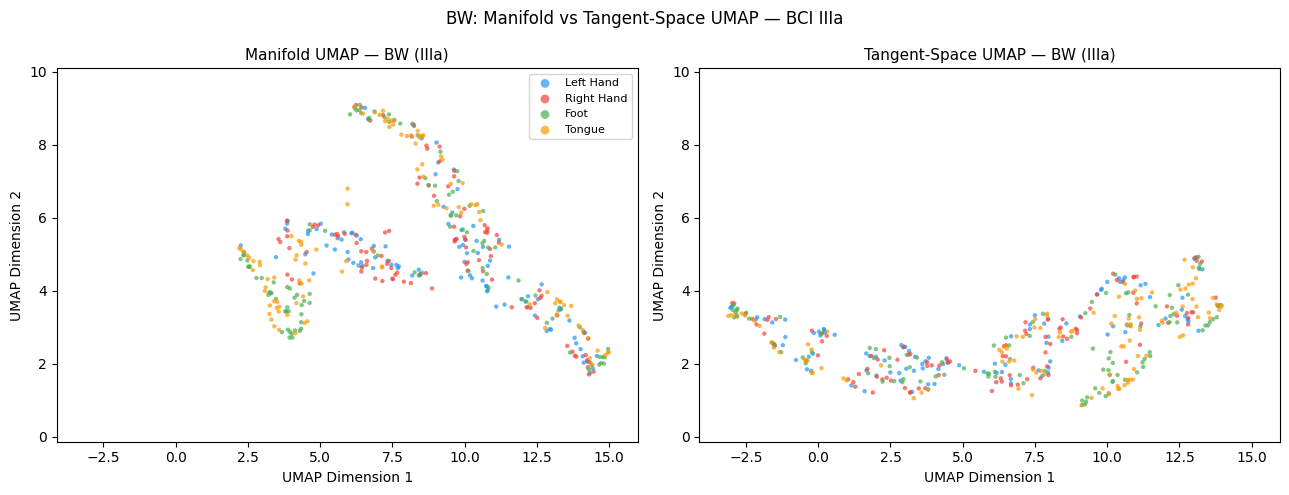

In [ ]:
# BW manifold UMAP
emb_manifold_bw = umap.UMAP(metric="precomputed", random_state=42).fit_transform(D)

# BW tangent-space UMAP
X_ppn = stack_npp_to_ppn(X_3a_train)
M_bw, _ = compute_mean_projection(X_ppn, metric="bw")
Z_bw = project_stack_to_tangent_features(X_3a_train, M_bw, metric="bw")
emb_tangent_bw = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_bw)

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_bw[:,0], emb_tangent_bw[:,0]])
all_y = np.concatenate([emb_manifold_bw[:,1], emb_tangent_bw[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_bw, y_3a_train, "Manifold UMAP — BW (IIIa)", ax=axes[0])
plot_umap_classified(emb_tangent_bw,  y_3a_train, "Tangent-Space UMAP — BW (IIIa)", ax=axes[1])
axes[1].get_legend().remove()
plt.suptitle("BW: Manifold vs Tangent-Space UMAP — BCI IIIa", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.1.3 AI Comparison

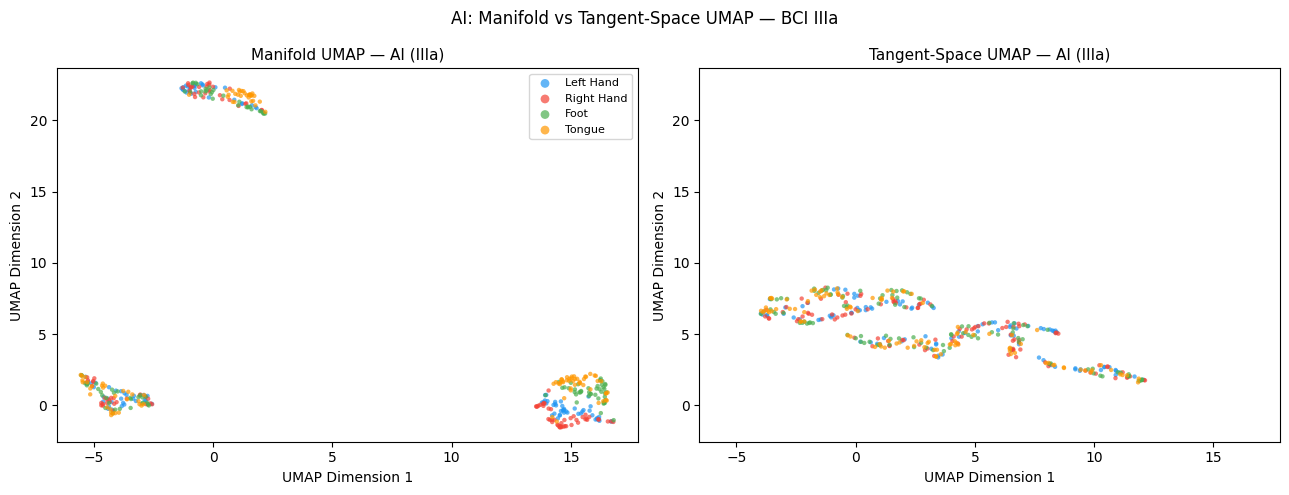

In [ ]:
# AI manifold UMAP
emb_manifold_ai = umap.UMAP(metric="precomputed", random_state=42).fit_transform(E)

# AI tangent-space UMAP
X_ppn = stack_npp_to_ppn(X_3a_train)
M_ai, _ = compute_mean_projection(X_ppn, metric="ai")
Z_ai = project_stack_to_tangent_features(X_3a_train, M_ai, metric="ai")
emb_tangent_ai = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_ai)

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_ai[:,0], emb_tangent_ai[:,0]])
all_y = np.concatenate([emb_manifold_ai[:,1], emb_tangent_ai[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_ai, y_3a_train, "Manifold UMAP — AI (IIIa)", ax=axes[0])
plot_umap_classified(emb_tangent_ai,  y_3a_train, "Tangent-Space UMAP — AI (IIIa)", ax=axes[1])
axes[1].get_legend().remove()
plt.suptitle("AI: Manifold vs Tangent-Space UMAP — BCI IIIa", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.1.4 LogE Comparison

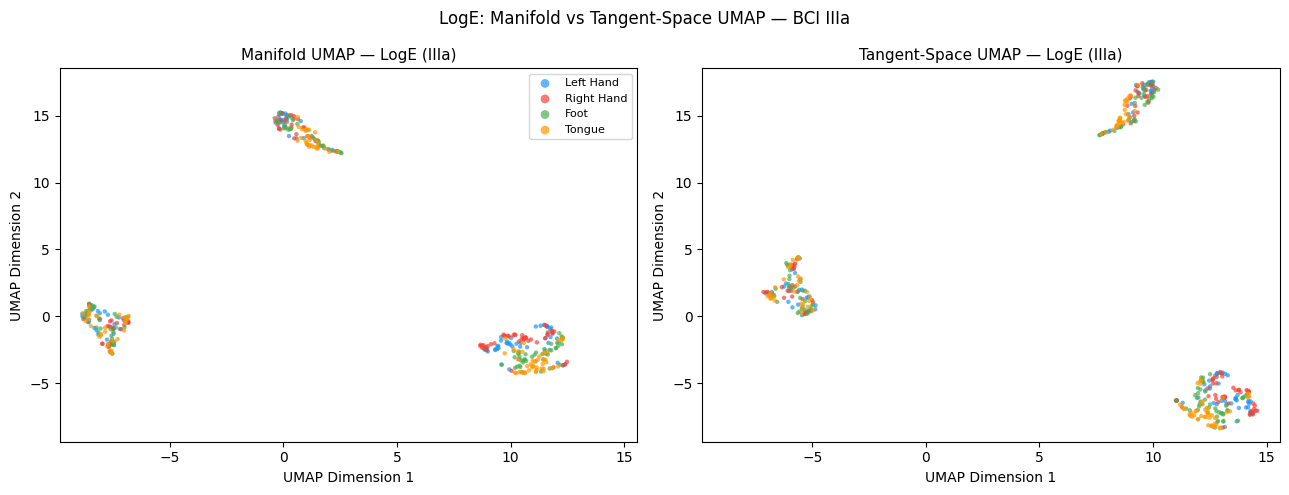

In [ ]:
# LogE manifold UMAP
emb_manifold_loge = umap.UMAP(metric="precomputed", random_state=42).fit_transform(F)

# LogE tangent-space UMAP
X_ppn = stack_npp_to_ppn(X_3a_train)
M_loge, _ = compute_mean_projection(X_ppn, metric="loge")
Z_loge = project_stack_to_tangent_features(X_3a_train, M_loge, metric="loge")
emb_tangent_loge = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_loge)

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_loge[:,0], emb_tangent_loge[:,0]])
all_y = np.concatenate([emb_manifold_loge[:,1], emb_tangent_loge[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_loge, y_3a_train, "Manifold UMAP — LogE (IIIa)", ax=axes[0])
plot_umap_classified(emb_tangent_loge,  y_3a_train, "Tangent-Space UMAP — LogE (IIIa)", ax=axes[1])
axes[1].get_legend().remove()
plt.suptitle("LogE: Manifold vs Tangent-Space UMAP — BCI IIIa", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.1.5 Geometric Metrics (Neighborhood Overlap, Trustworthiness, Spearman)

In [ ]:
k = 10
results_task1_3a = {}
for metric_name, D_mat, Z_mat in zip(["BW","AI","LogE"], [D,E,F], [Z_bw,Z_ai,Z_loge]):
    nbrs_m = NearestNeighbors(n_neighbors=k, metric="precomputed").fit(D_mat)
    idx_m  = nbrs_m.kneighbors(D_mat, return_distance=False)
    nbrs_t = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(Z_mat)
    idx_t  = nbrs_t.kneighbors(Z_mat, return_distance=False)
    overlaps = [len(set(idx_m[i]) & set(idx_t[i])) / k for i in range(len(Z_mat))]
    trust = trustworthiness(D_mat, Z_mat, n_neighbors=k, metric="precomputed")
    D_tan = cdist(Z_mat, Z_mat, metric="euclidean")
    ix = np.triu_indices(len(Z_mat), k=1)
    spear, _ = spearmanr(D_mat[ix], D_tan[ix])
    results_task1_3a[metric_name] = (np.mean(overlaps), trust, spear)
    print(f"{metric_name}: Overlap={np.mean(overlaps):.4f} | Trust={trust:.4f} | Spearman={spear:.4f}")

# Display as table
rows = [{'Geometry': m, 'Neighborhood Overlap': f"{v[0]:.4f}",
         'Trustworthiness': f"{v[1]:.4f}", 'Spearman Correlation': f"{v[2]:.4f}"}
        for m, v in results_task1_3a.items()]
df = pd.DataFrame(rows).set_index('Geometry')
metric_cols = ['Neighborhood Overlap','Trustworthiness','Spearman Correlation']
best_vals = {m: max(float(r[m]) for r in rows) for m in metric_cols}
s = (df.style.set_caption("Task 1 — Geometric Fidelity of Tangent Projection (BCI IIIa)")
       .set_table_styles(STYLE_CONFIG)
       .apply(lambda col: ["font-weight:bold;color:#16a34a;" if float(v)==best_vals.get(col.name) else "" for v in col], subset=metric_cols))
display(HTML("<h2>BCI IIIa — Task 1 Geometric Metrics</h2>"))
display(s)

BW: Overlap=0.6502 | Trust=0.9860 | Spearman=0.9331
AI: Overlap=0.2636 | Trust=0.8697 | Spearman=0.5350
LogE: Overlap=0.8786 | Trust=0.9990 | Spearman=0.9988


,Neighborhood Overlap,Trustworthiness,Spearman Correlation
Geometry,,,
BW,0.6502,0.9860,0.9331
AI,0.2636,0.8697,0.5350
LogE,0.8786,0.9990,0.9988


### 2.2 BCI IVa (20×20 subset, subject 'aa')
#### 2.2.1 Pairwise Distance Matrices

In [ ]:
D_4a = compute_pairwise_distance_matrix(X_small_4a, metric="bw")
E_4a = compute_pairwise_distance_matrix(X_small_4a, metric="ai")
F_4a = compute_pairwise_distance_matrix(X_small_4a, metric="loge")

Computed distances for row 1/168 (167/14028 pairs)
Computed distances for row 26/168 (4017/14028 pairs)
Computed distances for row 51/168 (7242/14028 pairs)
Computed distances for row 76/168 (9842/14028 pairs)
Computed distances for row 101/168 (11817/14028 pairs)
Computed distances for row 126/168 (13167/14028 pairs)
Computed distances for row 151/168 (13892/14028 pairs)
Computed distances for row 168/168 (14028/14028 pairs)
Computed distances for row 1/168 (167/14028 pairs)
Computed distances for row 26/168 (4017/14028 pairs)
Computed distances for row 51/168 (7242/14028 pairs)
Computed distances for row 76/168 (9842/14028 pairs)
Computed distances for row 101/168 (11817/14028 pairs)
Computed distances for row 126/168 (13167/14028 pairs)
Computed distances for row 151/168 (13892/14028 pairs)
Computed distances for row 168/168 (14028/14028 pairs)
Computed distances for row 1/168 (167/14028 pairs)
Computed distances for row 26/168 (4017/14028 pairs)
Computed distances for row 51/168 (7

#### 2.2.2 BW Comparison

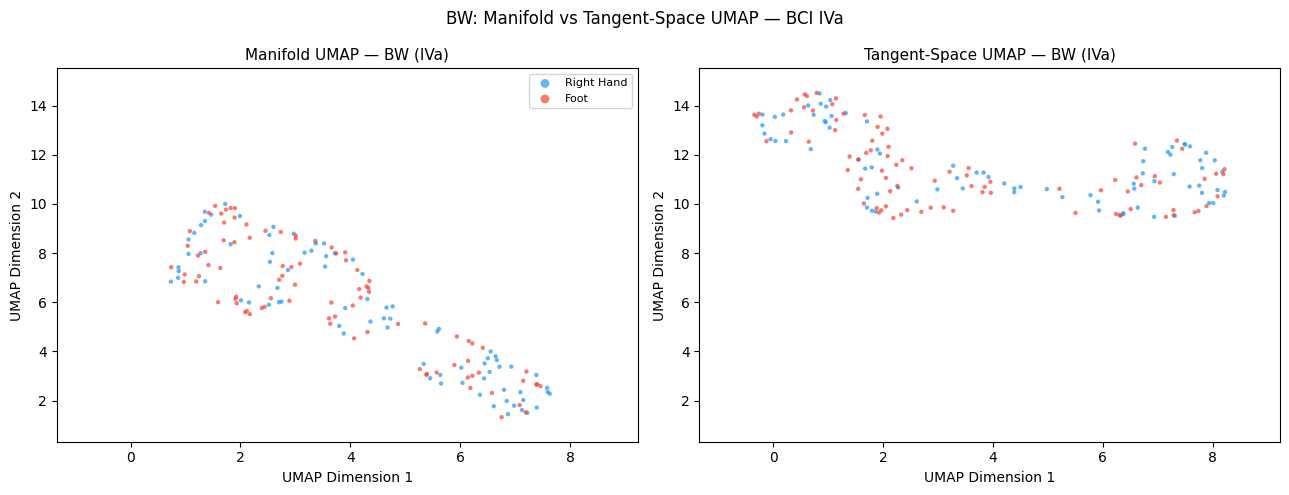

In [ ]:
emb_manifold_bw_4a = umap.UMAP(metric="precomputed", random_state=42).fit_transform(D_4a)
X_ppn_4a = stack_npp_to_ppn(X_small_4a)
M_bw_4a, _ = compute_mean_projection(X_ppn_4a, metric="bw")
Z_bw_4a = project_stack_to_tangent_features(X_small_4a, M_bw_4a, metric="bw")
emb_tangent_bw_4a = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_bw_4a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_bw_4a[:,0], emb_tangent_bw_4a[:,0]])
all_y = np.concatenate([emb_manifold_bw_4a[:,1], emb_tangent_bw_4a[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_bw_4a, y_small_4a, "Manifold UMAP — BW (IVa)", ax=axes[0], label_map=IVA_LABELS, color_map=IVA_COLORS)
plot_umap_classified(emb_tangent_bw_4a,  y_small_4a, "Tangent-Space UMAP — BW (IVa)", ax=axes[1], label_map=IVA_LABELS, color_map=IVA_COLORS)
axes[1].get_legend().remove()
plt.suptitle("BW: Manifold vs Tangent-Space UMAP — BCI IVa", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.2.3 AI Comparison

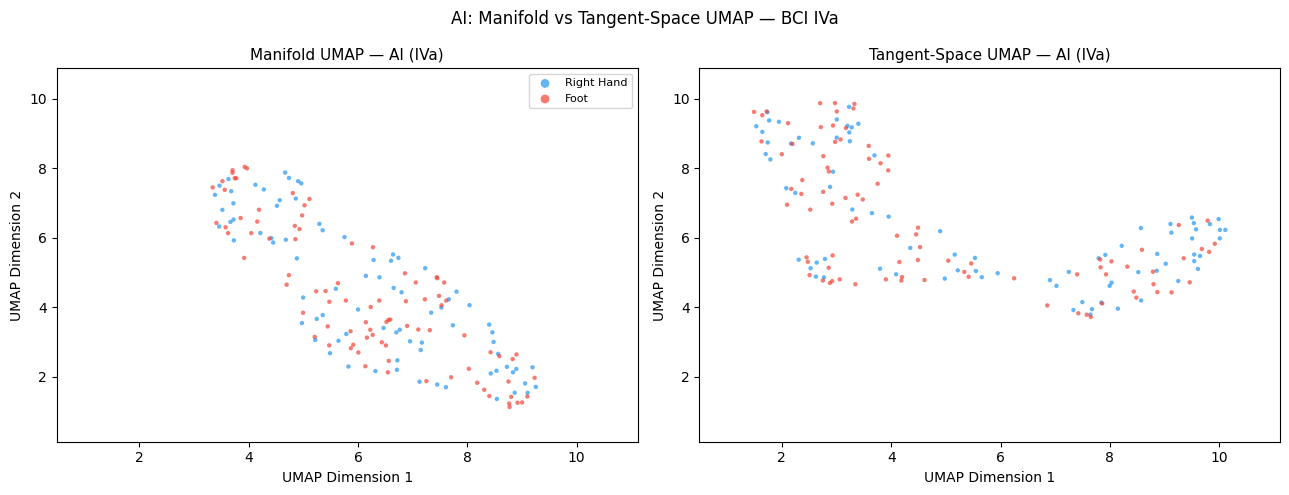

In [ ]:
emb_manifold_ai_4a = umap.UMAP(metric="precomputed", random_state=42).fit_transform(E_4a)
X_ppn_4a = stack_npp_to_ppn(X_small_4a)
M_ai_4a, _ = compute_mean_projection(X_ppn_4a, metric="ai")
Z_ai_4a = project_stack_to_tangent_features(X_small_4a, M_ai_4a, metric="ai")
emb_tangent_ai_4a = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_ai_4a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_ai_4a[:,0], emb_tangent_ai_4a[:,0]])
all_y = np.concatenate([emb_manifold_ai_4a[:,1], emb_tangent_ai_4a[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_ai_4a, y_small_4a, "Manifold UMAP — AI (IVa)", ax=axes[0], label_map=IVA_LABELS, color_map=IVA_COLORS)
plot_umap_classified(emb_tangent_ai_4a,  y_small_4a, "Tangent-Space UMAP — AI (IVa)", ax=axes[1], label_map=IVA_LABELS, color_map=IVA_COLORS)
axes[1].get_legend().remove()
plt.suptitle("AI: Manifold vs Tangent-Space UMAP — BCI IVa", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.2.4 LogE Comparison

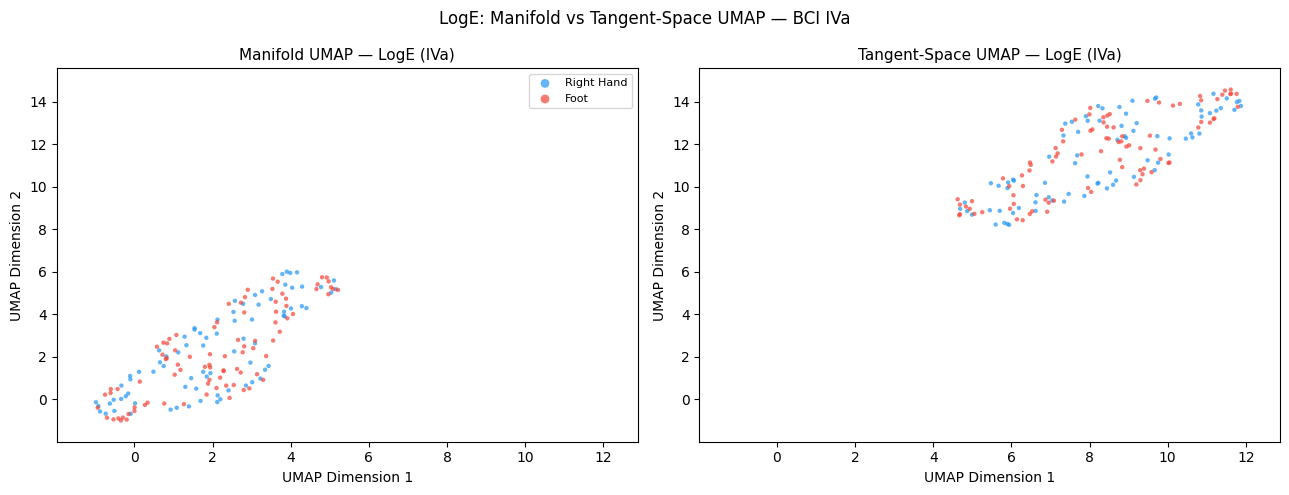

In [ ]:
emb_manifold_loge_4a = umap.UMAP(metric="precomputed", random_state=42).fit_transform(F_4a)
X_ppn_4a = stack_npp_to_ppn(X_small_4a)
M_loge_4a, _ = compute_mean_projection(X_ppn_4a, metric="loge")
Z_loge_4a = project_stack_to_tangent_features(X_small_4a, M_loge_4a, metric="loge")
emb_tangent_loge_4a = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_loge_4a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_loge_4a[:,0], emb_tangent_loge_4a[:,0]])
all_y = np.concatenate([emb_manifold_loge_4a[:,1], emb_tangent_loge_4a[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_loge_4a, y_small_4a, "Manifold UMAP — LogE (IVa)", ax=axes[0], label_map=IVA_LABELS, color_map=IVA_COLORS)
plot_umap_classified(emb_tangent_loge_4a,  y_small_4a, "Tangent-Space UMAP — LogE (IVa)", ax=axes[1], label_map=IVA_LABELS, color_map=IVA_COLORS)
axes[1].get_legend().remove()
plt.suptitle("LogE: Manifold vs Tangent-Space UMAP — BCI IVa", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.2.5 Geometric Metrics

In [ ]:
k = 10
results_task1_4a = {}
for metric_name, D_mat, Z_mat in zip(["BW","AI","LogE"], [D_4a,E_4a,F_4a], [Z_bw_4a,Z_ai_4a,Z_loge_4a]):
    nbrs_m = NearestNeighbors(n_neighbors=k, metric="precomputed").fit(D_mat)
    idx_m  = nbrs_m.kneighbors(D_mat, return_distance=False)
    nbrs_t = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(Z_mat)
    idx_t  = nbrs_t.kneighbors(Z_mat, return_distance=False)
    overlaps = [len(set(idx_m[i]) & set(idx_t[i])) / k for i in range(len(Z_mat))]
    trust = trustworthiness(D_mat, Z_mat, n_neighbors=k, metric="precomputed")
    D_tan = cdist(Z_mat, Z_mat, metric="euclidean")
    ix = np.triu_indices(len(Z_mat), k=1)
    spear, _ = spearmanr(D_mat[ix], D_tan[ix])
    results_task1_4a[metric_name] = (np.mean(overlaps), trust, spear)
    print(f"{metric_name}: Overlap={np.mean(overlaps):.4f} | Trust={trust:.4f} | Spearman={spear:.4f}")

rows = [{'Geometry': m, 'Neighborhood Overlap': f"{v[0]:.4f}",
         'Trustworthiness': f"{v[1]:.4f}", 'Spearman Correlation': f"{v[2]:.4f}"}
        for m, v in results_task1_4a.items()]
df = pd.DataFrame(rows).set_index('Geometry')
metric_cols = ['Neighborhood Overlap','Trustworthiness','Spearman Correlation']
best_vals = {m: max(float(r[m]) for r in rows) for m in metric_cols}
s = (df.style.set_caption("Task 1 — Geometric Fidelity of Tangent Projection (BCI IVa, 20×20 subset)")
       .set_table_styles(STYLE_CONFIG)
       .apply(lambda col: ["font-weight:bold;color:#16a34a;" if float(v)==best_vals.get(col.name) else "" for v in col], subset=metric_cols))
display(HTML("<h2>BCI IVa — Task 1 Geometric Metrics</h2>"))
display(s)

BW: Overlap=0.6976 | Trust=0.9735 | Spearman=0.9004
AI: Overlap=0.3185 | Trust=0.7612 | Spearman=0.3231
LogE: Overlap=0.8673 | Trust=0.9972 | Spearman=0.9954


,Neighborhood Overlap,Trustworthiness,Spearman Correlation
Geometry,,,
BW,0.6976,0.9735,0.9004
AI,0.3185,0.7612,0.3231
LogE,0.8673,0.9972,0.9954


### 2.3 PhysioNet
#### 2.3.1 Pairwise Distance Matrices

In [ ]:
# PhysioNet Task 1 — run after data is loaded
D_phys = compute_pairwise_distance_matrix(X_phys_small, metric="bw")
E_phys = compute_pairwise_distance_matrix(X_phys_small, metric="ai")
F_phys = compute_pairwise_distance_matrix(X_phys_small, metric="loge")

Computed distances for row 1/500 (499/124750 pairs)
Computed distances for row 26/500 (12649/124750 pairs)
Computed distances for row 51/500 (24174/124750 pairs)
Computed distances for row 76/500 (35074/124750 pairs)
Computed distances for row 101/500 (45349/124750 pairs)
Computed distances for row 126/500 (54999/124750 pairs)
Computed distances for row 151/500 (64024/124750 pairs)
Computed distances for row 176/500 (72424/124750 pairs)
Computed distances for row 201/500 (80199/124750 pairs)
Computed distances for row 226/500 (87349/124750 pairs)
Computed distances for row 251/500 (93874/124750 pairs)
Computed distances for row 276/500 (99774/124750 pairs)
Computed distances for row 301/500 (105049/124750 pairs)
Computed distances for row 326/500 (109699/124750 pairs)
Computed distances for row 351/500 (113724/124750 pairs)
Computed distances for row 376/500 (117124/124750 pairs)
Computed distances for row 401/500 (119899/124750 pairs)
Computed distances for row 426/500 (122049/124750 

#### 2.3.2 BW Comparison

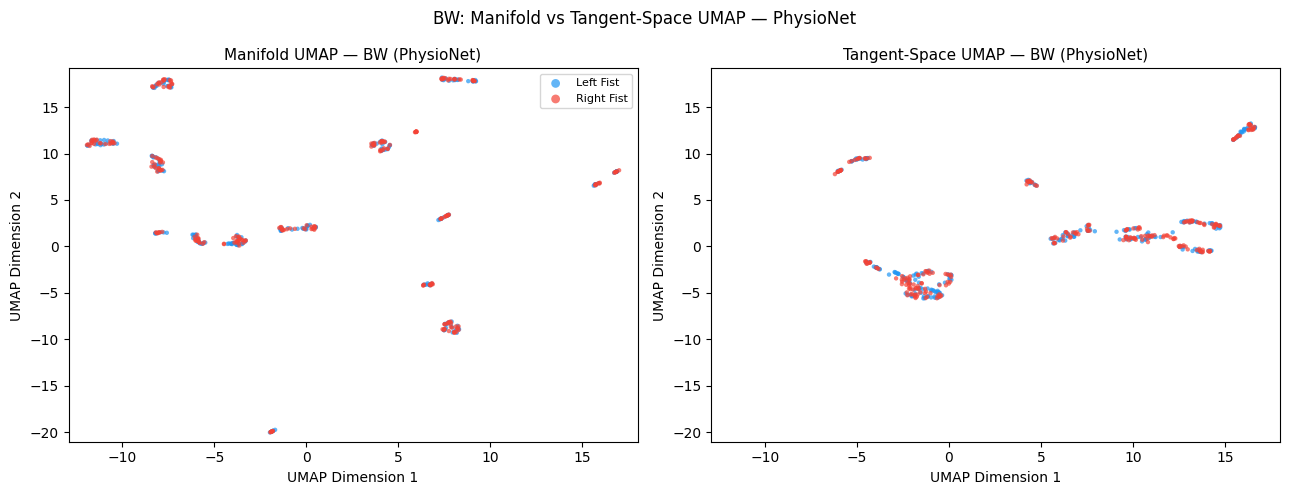

In [ ]:
# ── BW ────────────────────────────────────────────────────────
emb_manifold_bw_phys = umap.UMAP(metric="precomputed", random_state=42).fit_transform(D_phys)

X_ppn_phys = stack_npp_to_ppn(X_phys_small)
M_bw_phys, _ = compute_mean_projection(X_ppn_phys, metric="bw")
Z_bw_phys = project_stack_to_tangent_features(X_phys_small, M_bw_phys, metric="bw")
emb_tangent_bw_phys = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_bw_phys)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_bw_phys[:,0], emb_tangent_bw_phys[:,0]])
all_y = np.concatenate([emb_manifold_bw_phys[:,1], emb_tangent_bw_phys[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_bw_phys, y_phys_small, "Manifold UMAP — BW (PhysioNet)",
                     ax=axes[0], label_map=PHYS_LABELS, color_map=PHYS_COLORS)
plot_umap_classified(emb_tangent_bw_phys,  y_phys_small, "Tangent-Space UMAP — BW (PhysioNet)",
                     ax=axes[1], label_map=PHYS_LABELS, color_map=PHYS_COLORS)
axes[1].get_legend().remove()
plt.suptitle("BW: Manifold vs Tangent-Space UMAP — PhysioNet", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.3.3 AI Comparison

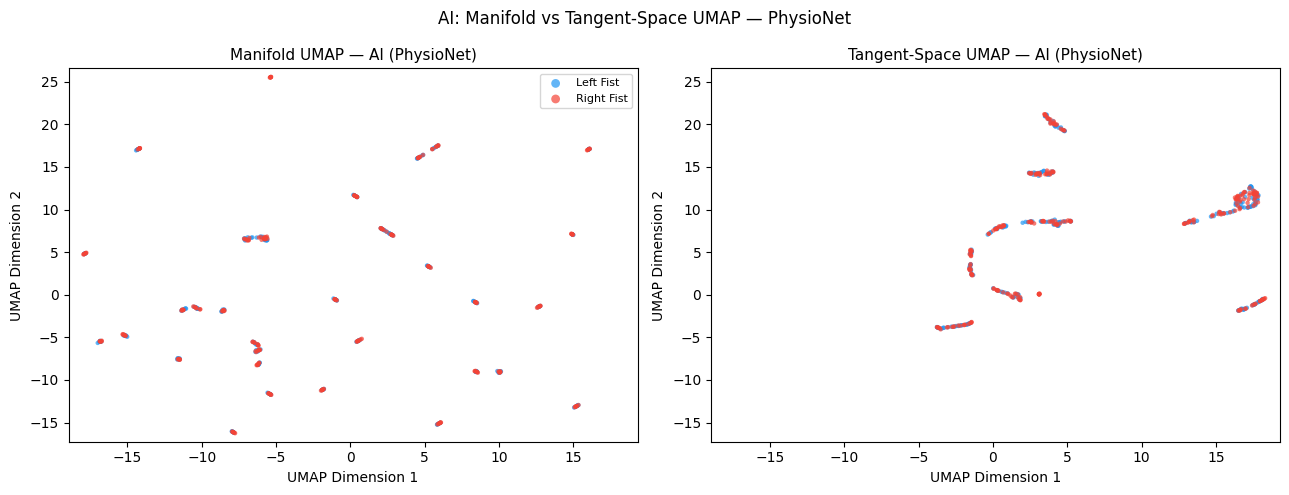

In [ ]:
# ── AI ────────────────────────────────────────────────────────
emb_manifold_ai_phys = umap.UMAP(metric="precomputed", random_state=42).fit_transform(E_phys)

X_ppn_phys = stack_npp_to_ppn(X_phys_small)
M_ai_phys, _ = compute_mean_projection(X_ppn_phys, metric="ai")
Z_ai_phys = project_stack_to_tangent_features(X_phys_small, M_ai_phys, metric="ai")
emb_tangent_ai_phys = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_ai_phys)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_ai_phys[:,0], emb_tangent_ai_phys[:,0]])
all_y = np.concatenate([emb_manifold_ai_phys[:,1], emb_tangent_ai_phys[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_ai_phys, y_phys_small, "Manifold UMAP — AI (PhysioNet)",
                     ax=axes[0], label_map=PHYS_LABELS, color_map=PHYS_COLORS)
plot_umap_classified(emb_tangent_ai_phys,  y_phys_small, "Tangent-Space UMAP — AI (PhysioNet)",
                     ax=axes[1], label_map=PHYS_LABELS, color_map=PHYS_COLORS)
axes[1].get_legend().remove()
plt.suptitle("AI: Manifold vs Tangent-Space UMAP — PhysioNet", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.3.4 LogE Comparison

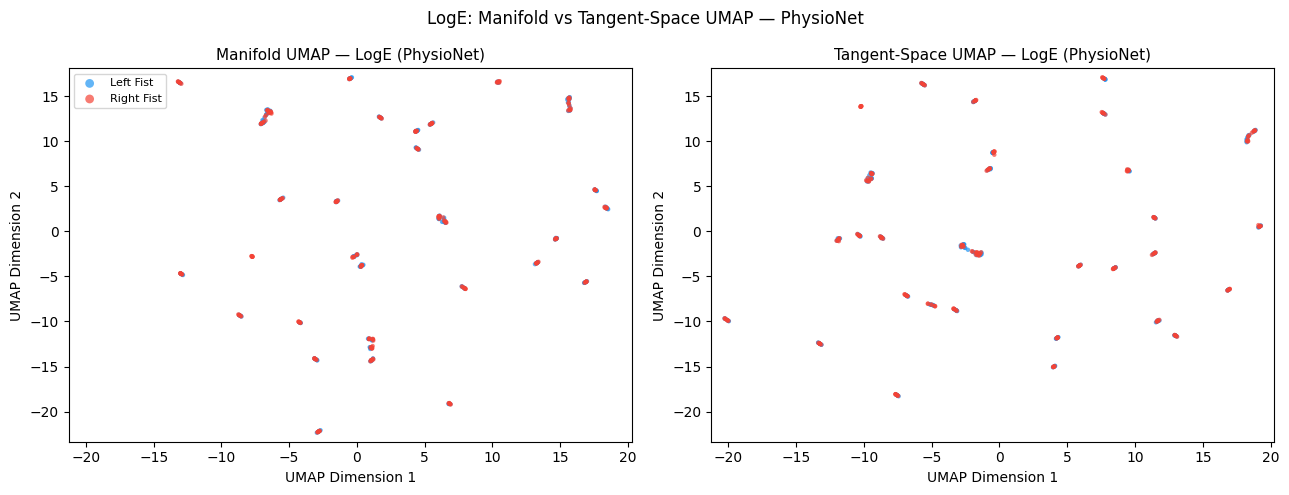

In [ ]:
# ── LogE ──────────────────────────────────────────────────────
emb_manifold_loge_phys = umap.UMAP(metric="precomputed", random_state=42).fit_transform(F_phys)

X_ppn_phys = stack_npp_to_ppn(X_phys_small)
M_loge_phys, _ = compute_mean_projection(X_ppn_phys, metric="loge")
Z_loge_phys = project_stack_to_tangent_features(X_phys_small, M_loge_phys, metric="loge")
emb_tangent_loge_phys = umap.UMAP(metric="euclidean", random_state=42).fit_transform(Z_loge_phys)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_x = np.concatenate([emb_manifold_loge_phys[:,0], emb_tangent_loge_phys[:,0]])
all_y = np.concatenate([emb_manifold_loge_phys[:,1], emb_tangent_loge_phys[:,1]])
for ax in axes:
    ax.set_xlim(all_x.min()-1, all_x.max()+1)
    ax.set_ylim(all_y.min()-1, all_y.max()+1)
plot_umap_classified(emb_manifold_loge_phys, y_phys_small, "Manifold UMAP — LogE (PhysioNet)",
                     ax=axes[0], label_map=PHYS_LABELS, color_map=PHYS_COLORS)
plot_umap_classified(emb_tangent_loge_phys,  y_phys_small, "Tangent-Space UMAP — LogE (PhysioNet)",
                     ax=axes[1], label_map=PHYS_LABELS, color_map=PHYS_COLORS)
axes[1].get_legend().remove()
plt.suptitle("LogE: Manifold vs Tangent-Space UMAP — PhysioNet", fontsize=12)
plt.tight_layout(); plt.show()

#### 2.3.5 Geometric Metrics

In [ ]:
# ── Geometric Metrics ─────────────────────────────────────────
k = 10
results_task1_phys = {}
for metric_name, D_mat, Z_mat in zip(
        ["BW","AI","LogE"],
        [D_phys, E_phys, F_phys],
        [Z_bw_phys, Z_ai_phys, Z_loge_phys]):

    nbrs_m = NearestNeighbors(n_neighbors=k, metric="precomputed").fit(D_mat)
    idx_m  = nbrs_m.kneighbors(D_mat, return_distance=False)
    nbrs_t = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(Z_mat)
    idx_t  = nbrs_t.kneighbors(Z_mat, return_distance=False)
    overlaps = [len(set(idx_m[i]) & set(idx_t[i])) / k for i in range(len(Z_mat))]
    trust = trustworthiness(D_mat, Z_mat, n_neighbors=k, metric="precomputed")
    D_tan = cdist(Z_mat, Z_mat, metric="euclidean")
    ix = np.triu_indices(len(Z_mat), k=1)
    spear, _ = spearmanr(D_mat[ix], D_tan[ix])
    results_task1_phys[metric_name] = (np.mean(overlaps), trust, spear)
    print(f"{metric_name}: Overlap={np.mean(overlaps):.4f} | Trust={trust:.4f} | Spearman={spear:.4f}")

# display as table
rows = [{'Geometry': m, 'Neighborhood Overlap': f"{v[0]:.4f}",
         'Trustworthiness': f"{v[1]:.4f}", 'Spearman Correlation': f"{v[2]:.4f}"}
        for m, v in results_task1_phys.items()]
df = pd.DataFrame(rows).set_index('Geometry')
metric_cols = ['Neighborhood Overlap','Trustworthiness','Spearman Correlation']
best_vals = {m: max(float(r[m]) for r in rows) for m in metric_cols}
s = (df.style
       .set_caption("Task 1 — Geometric Fidelity of Tangent Projection (PhysioNet)")
       .set_table_styles(STYLE_CONFIG)
       .apply(lambda col: ["font-weight:bold;color:#16a34a;"
                           if float(v)==best_vals.get(col.name) else ""
                           for v in col], subset=metric_cols))
display(HTML("<h2>PhysioNet — Task 1 Geometric Metrics</h2>"))
display(s)

BW: Overlap=0.6158 | Trust=0.9863 | Spearman=0.8577
AI: Overlap=0.4330 | Trust=0.9687 | Spearman=0.3902
LogE: Overlap=0.9508 | Trust=0.9998 | Spearman=0.9952


,Neighborhood Overlap,Trustworthiness,Spearman Correlation
Geometry,,,
BW,0.6158,0.9863,0.8577
AI,0.4330,0.9687,0.3902
LogE,0.9508,0.9998,0.9952


---
## 3. Task 2: Classification
### 3.1 BCI IIIa
#### 3.1.1 Nested Cross-Validation

In [ ]:
results_3a_loge, pipeline_configs = run_nested_cv(X_3a_train, y_3a_train, metric='loge', n_outer=5)


  Nested CV | Geometry: LOGE | Dataset: BCI IIIa
  ── Fold 1/5 ──
  ── Fold 2/5 ──
  ── Fold 3/5 ──
  ── Fold 4/5 ──
  ── Fold 5/5 ──


In [ ]:
results_3a_bw, _ = run_nested_cv(X_3a_train, y_3a_train, metric='bw', n_outer=5)


  Nested CV | Geometry: BW | Dataset: BCI IIIa
  ── Fold 1/5 ──
  ── Fold 2/5 ──
  ── Fold 3/5 ──


In [ ]:
results_3a_ai, _ = run_nested_cv(X_3a_train, y_3a_train, metric='ai', n_outer=5)

#### 3.1.2 CV Results — Full Tables

In [ ]:
for metric_name, results in zip(['loge','bw','ai'],
                                  [results_3a_loge, results_3a_bw, results_3a_ai]):
    create_split_tables(results, pipeline_configs, metric_name)

#### 3.1.3 Final Model Evaluation on Held-Out Test Set

In [ ]:
LR = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)

res_loge_raw = evaluate_final_model(X_3a_train, y_3a_train, X_3a_test, y_3a_test, 'loge', None, None, False, 'LogReg', LR)
res_loge_std = evaluate_final_model(X_3a_train, y_3a_train, X_3a_test, y_3a_test, 'loge', None, None, True,  'LogReg', LR)
res_bw_raw   = evaluate_final_model(X_3a_train, y_3a_train, X_3a_test, y_3a_test, 'bw',   None, None, False, 'LogReg', LR)
res_bw_std   = evaluate_final_model(X_3a_train, y_3a_train, X_3a_test, y_3a_test, 'bw',   None, None, True,  'LogReg', LR)
res_ai_raw   = evaluate_final_model(X_3a_train, y_3a_train, X_3a_test, y_3a_test, 'ai',   None, None, False, 'LogReg', LR)
res_ai_std   = evaluate_final_model(X_3a_train, y_3a_train, X_3a_test, y_3a_test, 'ai',   None, None, True,  'LogReg', LR)

display_final_results_table([res_loge_raw, res_bw_raw, res_ai_raw], title="FINAL TEST RESULTS — RAW Features (BCI IIIa)", dataset="BCI IIIa")
display_final_results_table([res_loge_std, res_bw_std, res_ai_std], title="FINAL TEST RESULTS — STANDARDIZED Features (BCI IIIa)", dataset="BCI IIIa")

#### 3.1.4 Pipeline Summary

In [ ]:
display_pipeline_summary(
    results_dict={'LogE': results_3a_loge, 'BW': results_3a_bw, 'AI': results_3a_ai},
    pipeline_configs=pipeline_configs, dataset="BCI IIIa")

#### 3.1.5 Kappa Heatmap

In [ ]:
kappa_heatmap(
    results_dict={'LogE': results_3a_loge, 'BW': results_3a_bw, 'AI': results_3a_ai},
    pipeline_configs=pipeline_configs,
    title="BCI IIIa — Cohen's Kappa by Pipeline and Geometry (LogReg)",
    vmax=0.65)

#### 3.1.6 Training vs Test Comparison

In [ ]:
display_train_vs_test(
    cv_results_dict={'loge': results_3a_loge, 'bw': results_3a_bw, 'ai': results_3a_ai},
    pipeline_configs=pipeline_configs,
    test_results=[res_loge_raw, res_bw_raw, res_ai_raw],
    dataset="BCI IIIa")

### 3.2 BCI IVa (20×20 subset)
#### 3.2.1 Nested Cross-Validation

In [ ]:
results_4a_loge, pipeline_configs_4a = run_nested_cv_binary(X_4a_train_20, y_4a_train, metric='loge', n_outer=5, dataset='BCI IVa')

In [ ]:
results_4a_bw, _ = run_nested_cv_binary(X_4a_train_20, y_4a_train, metric='bw', n_outer=5, dataset='BCI IVa')

In [ ]:
results_4a_ai, _ = run_nested_cv_binary(X_4a_train_20, y_4a_train, metric='ai', n_outer=5, dataset='BCI IVa')

#### 3.2.2 CV Results — Full Tables

In [ ]:
for metric_name, results in zip(['loge','bw','ai'],
                                  [results_4a_loge, results_4a_bw, results_4a_ai]):
    create_split_tables(results, pipeline_configs_4a, metric_name)

#### 3.2.3 Final Model Evaluation

In [ ]:
LR = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)

res_4a_loge_raw = evaluate_final_model_binary(X_4a_train_20, y_4a_train, X_4a_test_20, y_4a_test, 'loge', None, None, False, 'LogReg', LR)
res_4a_loge_std = evaluate_final_model_binary(X_4a_train_20, y_4a_train, X_4a_test_20, y_4a_test, 'loge', None, None, True,  'LogReg', LR)
res_4a_bw_raw   = evaluate_final_model_binary(X_4a_train_20, y_4a_train, X_4a_test_20, y_4a_test, 'bw',   None, None, False, 'LogReg', LR)
res_4a_bw_std   = evaluate_final_model_binary(X_4a_train_20, y_4a_train, X_4a_test_20, y_4a_test, 'bw',   None, None, True,  'LogReg', LR)
res_4a_ai_raw   = evaluate_final_model_binary(X_4a_train_20, y_4a_train, X_4a_test_20, y_4a_test, 'ai',   None, None, False, 'LogReg', LR)
res_4a_ai_std   = evaluate_final_model_binary(X_4a_train_20, y_4a_train, X_4a_test_20, y_4a_test, 'ai',   None, None, True,  'LogReg', LR)

display_final_results_table([res_4a_loge_raw, res_4a_bw_raw, res_4a_ai_raw], title="FINAL TEST RESULTS — RAW (BCI IVa, 20×20)", dataset="BCI IVa")
display_final_results_table([res_4a_loge_std, res_4a_bw_std, res_4a_ai_std], title="FINAL TEST RESULTS — STD (BCI IVa, 20×20)", dataset="BCI IVa")

#### 3.2.4 Pipeline Summary

In [ ]:
display_pipeline_summary(
    results_dict={'LogE': results_4a_loge, 'BW': results_4a_bw, 'AI': results_4a_ai},
    pipeline_configs=pipeline_configs_4a, dataset="BCI IVa (20×20 subset)")

#### 3.2.5 Kappa Heatmap

In [ ]:
kappa_heatmap(
    results_dict={'LogE': results_4a_loge, 'BW': results_4a_bw, 'AI': results_4a_ai},
    pipeline_configs=pipeline_configs_4a,
    title="BCI IVa — Cohen's Kappa by Pipeline and Geometry (LogReg, 20×20 subset)",
    vmax=0.30)

#### 3.2.6 Training vs Test Comparison

In [ ]:
display_train_vs_test(
    cv_results_dict={'loge': results_4a_loge, 'bw': results_4a_bw, 'ai': results_4a_ai},
    pipeline_configs=pipeline_configs_4a,
    test_results=[res_4a_loge_raw, res_4a_bw_raw, res_4a_ai_raw],
    dataset="BCI IVa (20×20 subset)")

### 3.3 PhysioNet EEG Motor Imagery
#### 3.3.1 Nested Cross-Validation

In [ ]:
# ── Step 1: split once, use same split for all geometries ─────
### Using X_phys_small !!!

X_phys_tr, X_phys_te, y_phys_tr, y_phys_te = train_test_split(X_phys_small, y_phys_small, test_size=0.2, random_state=42, stratify=y_phys_small)

print("Train:", X_phys_tr.shape)
print("Test: ", X_phys_te.shape)

In [ ]:
# ── Step 2: nested CV on training set only ────────────────────
results_phys_loge, pipeline_configs_phys = run_nested_cv_binary(X_phys_tr, y_phys_tr, metric='loge', n_outer=5, dataset='PhysioNet')

In [ ]:
# ── Step 2: nested CV on training set only ────────────────────
results_phys_bw, pipeline_configs_phys = run_nested_cv_binary(X_phys_tr, y_phys_tr, metric='bw', n_outer=5, dataset='PhysioNet')

In [ ]:
# ── Step 2: nested CV on training set only ────────────────────
results_phys_ai, pipeline_configs_phys = run_nested_cv_binary(X_phys_tr, y_phys_tr, metric='ai', n_outer=5, dataset='PhysioNet')

#### 3.3.2 Final Model Evaluation

In [ ]:
# ── Step 3: final model on held-out test set ──────────────────
LR = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)

res_phys_loge_raw = evaluate_final_model_binary(
    X_phys_tr, y_phys_tr, X_phys_te, y_phys_te,
    metric='loge', reduction=None, q=None, standardize=False,
    clf_name='LogReg', clf=LR)

res_phys_loge_std = evaluate_final_model_binary(
    X_phys_tr, y_phys_tr, X_phys_te, y_phys_te,
    metric='loge', reduction=None, q=None, standardize=True,
    clf_name='LogReg', clf=LR)

res_phys_bw_raw = evaluate_final_model_binary(
    X_phys_tr, y_phys_tr, X_phys_te, y_phys_te,
    metric='bw', reduction=None, q=None, standardize=False,
    clf_name='LogReg', clf=LR)

res_phys_bw_std = evaluate_final_model_binary(
    X_phys_tr, y_phys_tr, X_phys_te, y_phys_te,
    metric='bw', reduction=None, q=None, standardize=True,
    clf_name='LogReg', clf=LR)

res_phys_ai_raw = evaluate_final_model_binary(
    X_phys_tr, y_phys_tr, X_phys_te, y_phys_te,
    metric='ai', reduction=None, q=None, standardize=False,
    clf_name='LogReg', clf=LR)

res_phys_ai_std = evaluate_final_model_binary(
    X_phys_tr, y_phys_tr, X_phys_te, y_phys_te,
    metric='ai', reduction=None, q=None, standardize=True,
    clf_name='LogReg', clf=LR)

#### 3.3.3 CV Results — Full Tables

In [ ]:
# ── Step 4: display results ───────────────────────────────────
display_final_results_table(
    [res_phys_loge_raw, res_phys_bw_raw, res_phys_ai_raw],
    title="FINAL TEST RESULTS — RAW Features (PhysioNet)",
    dataset="PhysioNet")

display_final_results_table(
    [res_phys_loge_std, res_phys_bw_std, res_phys_ai_std],
    title="FINAL TEST RESULTS — STANDARDIZED Features (PhysioNet)",
    dataset="PhysioNet")

#### 3.3.4 Pipeline Summary

In [ ]:
display_pipeline_summary(
    results_dict={'LogE': results_phys_loge, 'BW': results_phys_bw, 'AI': results_phys_ai},
    pipeline_configs=pipeline_configs_phys, dataset="PhysioNet")

#### 3.3.5 Kappa Heatmap

In [ ]:
kappa_heatmap(
    results_dict={'LogE': results_phys_loge, 'BW': results_phys_bw, 'AI': results_phys_ai},
    pipeline_configs=pipeline_configs_phys,
    title="PhysioNet — Cohen's Kappa by Pipeline and Geometry",
    vmax=0.30)

#### 3.3.6 Training vs Test Comparison

In [ ]:
display_train_vs_test(
    cv_results_dict={'loge': results_phys_loge, 'bw': results_phys_bw, 'ai': results_phys_ai},
    pipeline_configs=pipeline_configs_phys,
    test_results=[res_phys_loge_raw, res_phys_bw_raw, res_phys_ai_raw],
    dataset="PhysioNet")

---
## 4. Task 3: Raw vs Standardized Tangent Features
### 4.1 BCI IIIa
#### 4.1.1 Setup — Tangent Features

In [ ]:
# BW
X_ppn = stack_npp_to_ppn(X_3a_train)
M_bw3, _ = compute_mean_projection(X_ppn, metric="bw")
Z_bw_3a = project_stack_to_tangent_features(X_3a_train, M_bw3, metric="bw")
Z_raw_bw_3a = Z_bw_3a
Z_std_bw_3a = StandardScaler().fit_transform(Z_bw_3a)

# AI
M_ai3, _ = compute_mean_projection(X_ppn, metric="ai")
Z_ai_3a = project_stack_to_tangent_features(X_3a_train, M_ai3, metric="ai")
Z_raw_ai_3a = Z_ai_3a
Z_std_ai_3a = StandardScaler().fit_transform(Z_ai_3a)

# LogE
M_loge3, _ = compute_mean_projection(X_ppn, metric="loge")
Z_loge_3a = project_stack_to_tangent_features(X_3a_train, M_loge3, metric="loge")
Z_raw_loge_3a = Z_loge_3a
Z_std_loge_3a = StandardScaler().fit_transform(Z_loge_3a)

print("Tangent feature shape (1830 features):", Z_bw_3a.shape)

Tangent feature shape (1830 features): (420, 1830)


#### 4.1.2 Feature Standard Deviations — All Three Metrics

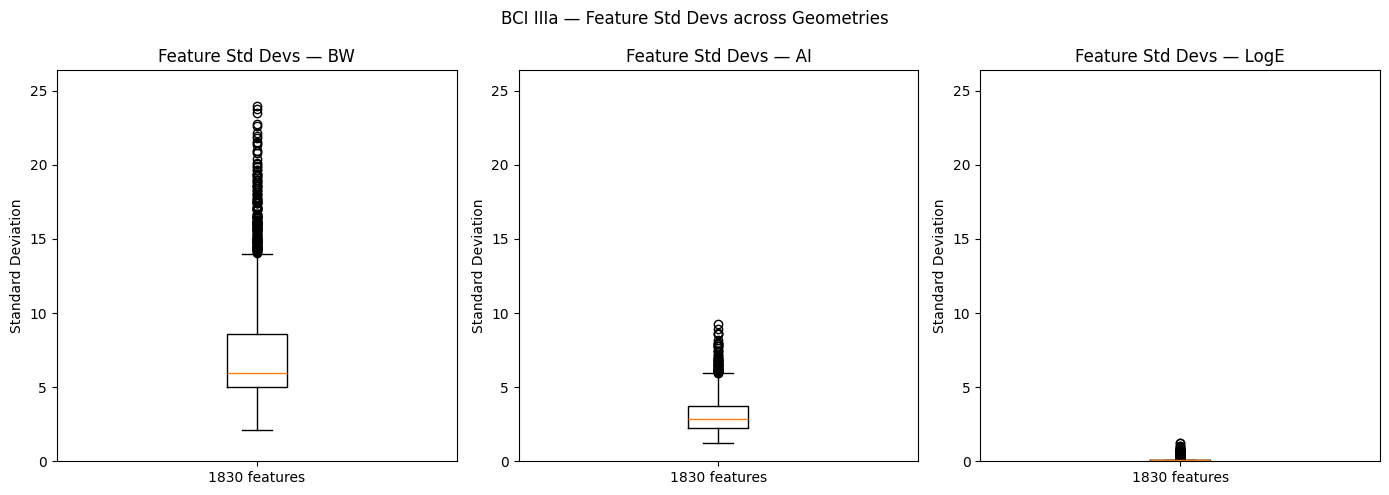

In [ ]:
# Combined boxplot — all three metrics
stds_all = [Z_bw_3a.std(axis=0), Z_ai_3a.std(axis=0), Z_loge_3a.std(axis=0)]
y_max = max(s.max() for s in stds_all) * 1.1

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, stds in zip(axes, ["BW","AI","LogE"], stds_all):
    ax.boxplot(stds)
    ax.set_title(f"Feature Std Devs — {metric}")
    ax.set_ylabel("Standard Deviation")
    ax.set_xticks([1]); ax.set_xticklabels(["1830 features"])
    ax.set_ylim(0, y_max)
plt.suptitle("BCI IIIa — Feature Std Devs across Geometries", fontsize=12)
plt.tight_layout(); plt.show()

#### 4.1.3 PCA Cumulative Variance — All Three Metrics

BW — Raw: 4 components | Std: 6 components to reach 95%
AI — Raw: 3 components | Std: 4 components to reach 95%
LogE — Raw: 199 components | Std: 337 components to reach 95%


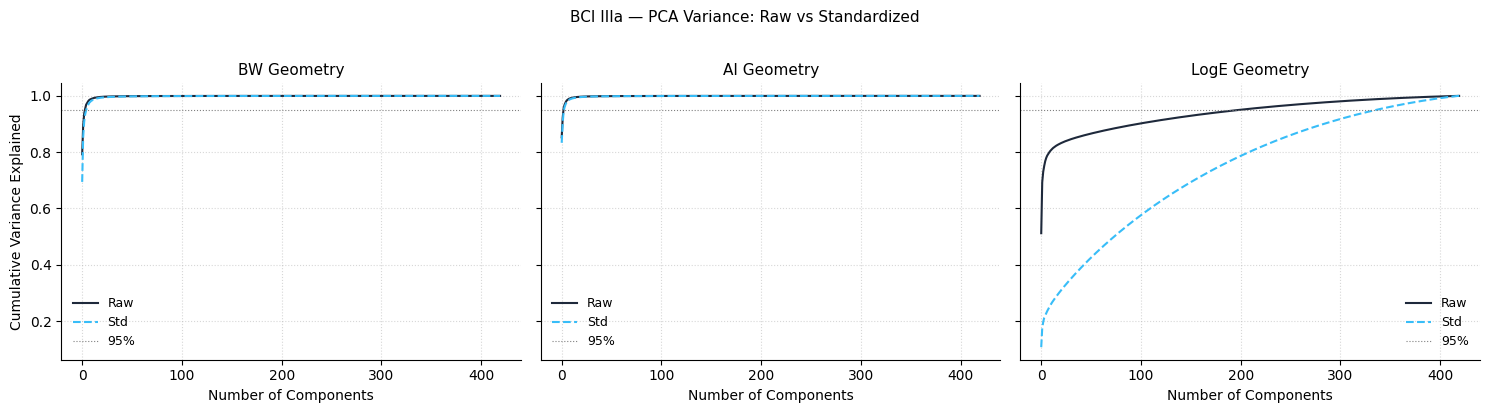

In [ ]:
# Combined PCA plot — all three metrics
pca_raws = [PCA().fit(Z_raw_bw_3a), PCA().fit(Z_raw_ai_3a), PCA().fit(Z_raw_loge_3a)]
pca_stds = [PCA().fit(Z_std_bw_3a), PCA().fit(Z_std_ai_3a), PCA().fit(Z_std_loge_3a)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric, pr, ps in zip(axes, ['BW','AI','LogE'], pca_raws, pca_stds):
    cum_r = np.cumsum(pr.explained_variance_ratio_)
    cum_s = np.cumsum(ps.explained_variance_ratio_)
    ax.plot(cum_r, label='Raw',  color='#1e293b', linewidth=1.5)
    ax.plot(cum_s, label='Std',  color='#38bdf8', linewidth=1.5, linestyle='--')
    ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8, label='95%')
    ax.set_title(f'{metric} Geometry', fontsize=11, fontweight='500')
    ax.set_xlabel("Number of Components")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
    n_raw = np.searchsorted(cum_r, 0.95) + 1
    n_std = np.searchsorted(cum_s, 0.95) + 1
    print(f"{metric} — Raw: {n_raw} components | Std: {n_std} components to reach 95%")
axes[0].set_ylabel("Cumulative Variance Explained")
plt.suptitle("BCI IIIa — PCA Variance: Raw vs Standardized", fontsize=11, fontweight='500', y=1.02)
plt.tight_layout(); plt.show()

#### 4.1.4 Classification Accuracy — Raw vs Standardized

In [ ]:
LR = LogisticRegression(max_iter=1000, solver='liblinear')

def classify_raw_vs_std(X_train, X_test, y_train, y_test, metric):
    X_ppn = stack_npp_to_ppn(X_train)
    M, _ = compute_mean_projection(X_ppn, metric=metric)
    Z_tr = project_stack_to_tangent_features(X_train, M, metric=metric)
    Z_te = project_stack_to_tangent_features(X_test,  M, metric=metric)
    scaler = StandardScaler()
    Z_tr_std = scaler.fit_transform(Z_tr)
    Z_te_std = scaler.transform(Z_te)
    clf_raw = clone(LR); clf_raw.fit(Z_tr, y_train)
    clf_std = clone(LR); clf_std.fit(Z_tr_std, y_train)
    return accuracy_score(y_test, clf_raw.predict(Z_te)), accuracy_score(y_test, clf_std.predict(Z_te_std))

acc_raw_bw_3a,   acc_std_bw_3a   = classify_raw_vs_std(X_3a_train, X_3a_test, y_3a_train, y_3a_test, 'bw')
acc_raw_ai_3a,   acc_std_ai_3a   = classify_raw_vs_std(X_3a_train, X_3a_test, y_3a_train, y_3a_test, 'ai')
acc_raw_loge_3a, acc_std_loge_3a = classify_raw_vs_std(X_3a_train, X_3a_test, y_3a_train, y_3a_test, 'loge')

print(f"BW   — Raw: {acc_raw_bw_3a:.4f} | Std: {acc_std_bw_3a:.4f}")
print(f"AI   — Raw: {acc_raw_ai_3a:.4f} | Std: {acc_std_ai_3a:.4f}")
print(f"LogE — Raw: {acc_raw_loge_3a:.4f} | Std: {acc_std_loge_3a:.4f}")

BW   — Raw: 0.6071 | Std: 0.6000
AI   — Raw: 0.6095 | Std: 0.5881
LogE — Raw: 0.7381 | Std: 0.6452


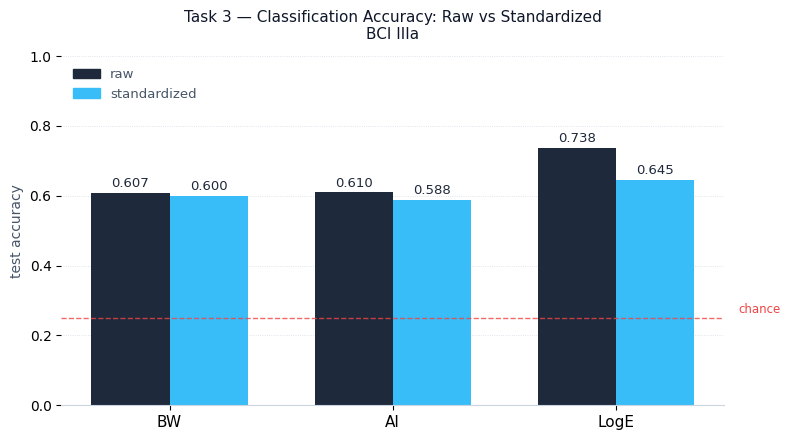

In [ ]:
# Grouped barplot
geometries_t3 = ['BW', 'AI', 'LogE']
acc_raw_vals  = [acc_raw_bw_3a, acc_raw_ai_3a, acc_raw_loge_3a]
acc_std_vals  = [acc_std_bw_3a, acc_std_ai_3a, acc_std_loge_3a]

x, width = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(8, 4.5)); fig.patch.set_facecolor('white')
bars_raw = ax.bar(x - width/2, acc_raw_vals, width, color='#1e293b', label='Raw')
bars_std = ax.bar(x + width/2, acc_std_vals, width, color='#38bdf8', label='Standardized')
for bar in list(bars_raw)+list(bars_std):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9.5, color='#1e293b')
ax.axhline(0.25, color='#ef4444', linestyle='--', linewidth=1.0, alpha=0.8)
ax.text(2.55, 0.255, 'chance', fontsize=8.5, color='#ef4444', va='bottom')
ax.set_ylim(0, 1.0); ax.set_xticks(x); ax.set_xticklabels(geometries_t3, fontsize=11)
ax.set_ylabel('test accuracy', fontsize=10, color='#475569')
ax.set_title('Task 3 — Classification Accuracy: Raw vs Standardized\nBCI IIIa', fontsize=11, fontweight='500', color='#0f172a', pad=12)
ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#cbd5e1', alpha=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top','right','left']: ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#cbd5e1')
legend_patches = [mpatches.Patch(color='#1e293b', label='raw'), mpatches.Patch(color='#38bdf8', label='standardized')]
ax.legend(handles=legend_patches, frameon=False, fontsize=9.5, loc='upper left', labelcolor='#475569')
plt.tight_layout(); plt.savefig('task3_acc_3a.png', dpi=200, bbox_inches='tight', facecolor='white'); plt.show()

### 4.2 BCI IVa (20×20 subset)
#### 4.2.1 Setup

In [ ]:
X_ppn_4 = stack_npp_to_ppn(X_4a_train_20)

M_bw4, _ = compute_mean_projection(X_ppn_4, metric="bw")
Z_bw_4 = project_stack_to_tangent_features(X_4a_train_20, M_bw4, metric="bw")
Z_raw_bw_4 = Z_bw_4; Z_std_bw_4 = StandardScaler().fit_transform(Z_bw_4)

M_ai4, _ = compute_mean_projection(X_ppn_4, metric="ai")
Z_ai_4 = project_stack_to_tangent_features(X_4a_train_20, M_ai4, metric="ai")
Z_raw_ai_4 = Z_ai_4; Z_std_ai_4 = StandardScaler().fit_transform(Z_ai_4)

M_loge4, _ = compute_mean_projection(X_ppn_4, metric="loge")
Z_loge_4 = project_stack_to_tangent_features(X_4a_train_20, M_loge4, metric="loge")
Z_raw_loge_4 = Z_loge_4; Z_std_loge_4 = StandardScaler().fit_transform(Z_loge_4)

print("Tangent feature shape (210 features):", Z_bw_4.shape)

#### 4.2.2 Feature Standard Deviations

In [ ]:
stds_all = [Z_bw_4.std(axis=0), Z_ai_4.std(axis=0), Z_loge_4.std(axis=0)]
y_max = max(s.max() for s in stds_all) * 1.1
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, stds in zip(axes, ["BW","AI","LogE"], stds_all):
    ax.boxplot(stds)
    ax.set_title(f"Feature Std Devs — {metric}")
    ax.set_ylabel("Standard Deviation")
    ax.set_xticks([1]); ax.set_xticklabels(["210 features"])
    ax.set_ylim(0, y_max)
plt.suptitle("BCI IVa — Feature Std Devs across Geometries", fontsize=12)
plt.tight_layout(); plt.show()

#### 4.2.3 PCA Cumulative Variance

In [ ]:
pca_raws_4 = [PCA().fit(Z_raw_bw_4), PCA().fit(Z_raw_ai_4), PCA().fit(Z_raw_loge_4)]
pca_stds_4 = [PCA().fit(Z_std_bw_4), PCA().fit(Z_std_ai_4), PCA().fit(Z_std_loge_4)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric, pr, ps in zip(axes, ['BW','AI','LogE'], pca_raws_4, pca_stds_4):
    cum_r = np.cumsum(pr.explained_variance_ratio_)
    cum_s = np.cumsum(ps.explained_variance_ratio_)
    ax.plot(cum_r, label='Raw',  color='#1e293b', linewidth=1.5)
    ax.plot(cum_s, label='Std',  color='#38bdf8', linewidth=1.5, linestyle='--')
    ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(f'{metric} Geometry', fontsize=11)
    ax.set_xlabel("Number of Components")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
axes[0].set_ylabel("Cumulative Variance Explained")
plt.suptitle("BCI IVa — PCA Variance: Raw vs Standardized", fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

#### 4.2.4 Classification Accuracy

In [ ]:
acc_raw_bw_4a,   acc_std_bw_4a   = classify_raw_vs_std(X_4a_train_20, X_4a_test_20, y_4a_train, y_4a_test, 'bw')
acc_raw_ai_4a,   acc_std_ai_4a   = classify_raw_vs_std(X_4a_train_20, X_4a_test_20, y_4a_train, y_4a_test, 'ai')
acc_raw_loge_4a, acc_std_loge_4a = classify_raw_vs_std(X_4a_train_20, X_4a_test_20, y_4a_train, y_4a_test, 'loge')

print(f"BW   — Raw: {acc_raw_bw_4a:.4f} | Std: {acc_std_bw_4a:.4f}")
print(f"AI   — Raw: {acc_raw_ai_4a:.4f} | Std: {acc_std_ai_4a:.4f}")
print(f"LogE — Raw: {acc_raw_loge_4a:.4f} | Std: {acc_std_loge_4a:.4f}")

# Grouped barplot
x, width = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(8, 4.5)); fig.patch.set_facecolor('white')
bars_raw = ax.bar(x - width/2, [acc_raw_bw_4a, acc_raw_ai_4a, acc_raw_loge_4a], width, color='#1e293b', label='Raw')
bars_std = ax.bar(x + width/2, [acc_std_bw_4a, acc_std_ai_4a, acc_std_loge_4a], width, color='#38bdf8', label='Standardized')
for bar in list(bars_raw)+list(bars_std):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9.5)
ax.axhline(0.50, color='#ef4444', linestyle='--', linewidth=1.0, alpha=0.8)
ax.text(2.55, 0.505, 'chance (50%)', fontsize=8.5, color='#ef4444', va='bottom')
ax.set_ylim(0, 1.0); ax.set_xticks(x); ax.set_xticklabels(['BW','AI','LogE'], fontsize=11)
ax.set_ylabel('test accuracy'); ax.set_title('Task 3 — BCI IVa (20×20 subset)', fontsize=11, fontweight='500')
ax.yaxis.grid(True, linestyle=':', alpha=0.5); ax.set_axisbelow(True)
for spine in ['top','right','left']: ax.spines[spine].set_visible(False)
legend_patches = [mpatches.Patch(color='#1e293b', label='raw'), mpatches.Patch(color='#38bdf8', label='standardized')]
ax.legend(handles=legend_patches, frameon=False, fontsize=9.5)
plt.tight_layout(); plt.savefig('task3_acc_4a.png', dpi=200, bbox_inches='tight', facecolor='white'); plt.show()

### 4.3 PhysioNet
#### 4.3.1 Setup

In [ ]:
X_p_tr, X_p_te, y_p_tr, y_p_te = train_test_split(
    X_phys_small, y_phys_small, test_size=0.3, random_state=42, stratify=y_phys_small)
print("Train:", X_p_tr.shape, "| Test:", X_p_te.shape)

In [ ]:
X_ppn_p = stack_npp_to_ppn(X_p_tr)

M_bw_p, _ = compute_mean_projection(X_ppn_p, metric="bw")
Z_bw_p = project_stack_to_tangent_features(X_p_tr, M_bw_p, metric="bw")
Z_std_bw_p = StandardScaler().fit_transform(Z_bw_p)

M_ai_p, _ = compute_mean_projection(X_ppn_p, metric="ai")
Z_ai_p = project_stack_to_tangent_features(X_p_tr, M_ai_p, metric="ai")
Z_std_ai_p = StandardScaler().fit_transform(Z_ai_p)

M_loge_p, _ = compute_mean_projection(X_ppn_p, metric="loge")
Z_loge_p = project_stack_to_tangent_features(X_p_tr, M_loge_p, metric="loge")
Z_std_loge_p = StandardScaler().fit_transform(Z_loge_p)

print("Tangent feature shape (2080 features):", Z_bw_p.shape)

#### 4.3.2 Feature Standard Deviations

In [ ]:
stds_all = [Z_bw_p.std(axis=0), Z_ai_p.std(axis=0), Z_loge_p.std(axis=0)]
y_max = max(s.max() for s in stds_all) * 1.1
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, stds in zip(axes, ["BW","AI","LogE"], stds_all):
    ax.boxplot(stds)
    ax.set_title(f"Feature Std Devs — {metric}")
    ax.set_ylabel("Standard Deviation")
    ax.set_xticks([1]); ax.set_xticklabels(["2080 features"])
    ax.set_ylim(0, y_max)
plt.suptitle("PhysioNet — Feature Std Devs across Geometries", fontsize=12)
plt.tight_layout(); plt.show()

#### 4.3.3 PCA Cumulative Variance

In [ ]:
pca_raws_p = [PCA().fit(Z_bw_p), PCA().fit(Z_ai_p), PCA().fit(Z_loge_p)]
pca_stds_p = [PCA().fit(Z_std_bw_p), PCA().fit(Z_std_ai_p), PCA().fit(Z_std_loge_p)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric, pr, ps in zip(axes, ['BW','AI','LogE'], pca_raws_p, pca_stds_p):
    cum_r = np.cumsum(pr.explained_variance_ratio_)
    cum_s = np.cumsum(ps.explained_variance_ratio_)
    ax.plot(cum_r, label='Raw',  color='#1e293b', linewidth=1.5)
    ax.plot(cum_s, label='Std',  color='#38bdf8', linewidth=1.5, linestyle='--')
    ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(f'{metric} Geometry', fontsize=11)
    ax.set_xlabel("Number of Components")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
axes[0].set_ylabel("Cumulative Variance Explained")
plt.suptitle("PhysioNet — PCA Variance: Raw vs Standardized", fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

#### 4.3.4 Classification Accuracy

In [ ]:
acc_results_phys = {}
for metric_str, metric_label in [("bw","BW"), ("ai","AI"), ("loge","LogE")]:
    X_ppn_p = stack_npp_to_ppn(X_p_tr)
    M, _ = compute_mean_projection(X_ppn_p, metric=metric_str)
    Z_tr = project_stack_to_tangent_features(X_p_tr, M, metric=metric_str)
    Z_te = project_stack_to_tangent_features(X_p_te, M, metric=metric_str)
    scaler = StandardScaler()
    Z_tr_std = scaler.fit_transform(Z_tr)
    Z_te_std = scaler.transform(Z_te)
    clf_raw = clone(LR); clf_raw.fit(Z_tr, y_p_tr)
    clf_std = clone(LR); clf_std.fit(Z_tr_std, y_p_tr)
    acc_results_phys[metric_str] = {
        'raw': accuracy_score(y_p_te, clf_raw.predict(Z_te)),
        'std': accuracy_score(y_p_te, clf_std.predict(Z_te_std))
    }
    print(f"{metric_label} — Raw: {acc_results_phys[metric_str]['raw']:.4f} | Std: {acc_results_phys[metric_str]['std']:.4f}")

### 4.4 Cross-Dataset Accuracy Comparison

In [ ]:
# ── Build cross-dataset accuracy dicts ───────────────────────
datasets    = ['BCI IIIa', 'BCI IVa\n(20×20)', 'PhysioNet\n(subset)']
metrics_bar = ['BW', 'AI', 'LogE']
colors      = {'BW': '#1e293b', 'AI': '#0ea5e9', 'LogE': '#10b981'}

raw_accs = {
    'BW':   [acc_raw_bw_3a,   acc_raw_bw_4a,   acc_results_phys['bw']['raw']],
    'AI':   [acc_raw_ai_3a,   acc_raw_ai_4a,   acc_results_phys['ai']['raw']],
    'LogE': [acc_raw_loge_3a, acc_raw_loge_4a, acc_results_phys['loge']['raw']],
}
std_accs = {
    'BW':   [acc_std_bw_3a,   acc_std_bw_4a,   acc_results_phys['bw']['std']],
    'AI':   [acc_std_ai_3a,   acc_std_ai_4a,   acc_results_phys['ai']['std']],
    'LogE': [acc_std_loge_3a, acc_std_loge_4a, acc_results_phys['loge']['std']],
}

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, accs, label in [(axes[0], raw_accs, 'Raw Features'), (axes[1], std_accs, 'Standardized Features')]:
    for i, metric in enumerate(metrics_bar):
        offset = (i - 1) * width * 2
        bars = ax.bar(x + offset, accs[metric], width*1.8,
                      label=metric, color=colors[metric], alpha=0.9)
        # add percentage labels on each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2,
                    height + 0.01,
                    f'{height:.0%}',
                    ha='center', va='bottom',
                    fontsize=7, color='#334155',
                    fontweight='500')
    ax.set_title(label, fontsize=11, fontweight='500')
    ax.set_xticks(x); ax.set_xticklabels(datasets, fontsize=10)
    ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1.15)  # ← bump up to make room for labels
    ax.legend(frameon=False, fontsize=9)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5); ax.set_axisbelow(True)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.suptitle("Task 3 — Classification Accuracy Across All Datasets", fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('task3_cross_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 5. Literature Review

*Add papers from Google Scholar and the BCI competition leaderboard here.*
*Leaderboard: https://www.bbci.de/competition/iii/results/*

| Dataset | Method | Metric | Value | Citation |
|---------|--------|--------|-------|----------|
| BCI IIIa | Our results (LogE, Pipeline A) | Kappa | 0.651 | This work |
| BCI IVa  | Our results (LogE, 20×20 subset) | Kappa | 0.203 | This work |
| BCI IIIa | Competition winner | Kappa | TBD | bbci.de leaderboard |
| BCI IVa  | Competition winner | Kappa | TBD | bbci.de leaderboard |

*Fill in additional rows after literature search.*

In [ ]:
# ── Compare performance across q values (5, 10, 20) ──────────
# Works for any results dict from run_nested_cv

def plot_q_comparison(results_dict, pipeline_configs, dataset_name, metric_key='kappa'):
    """
    For each geometry, plot mean CV kappa (or accuracy) across q values
    for PCA and UMAP pipelines, raw and standardized.
    """
    q_values    = [5, 10, 20]
    geometries  = list(results_dict.keys())
    reductions  = ['pca', 'umap']
    std_options = [('raw', False), ('std', True)]

    fig, axes = plt.subplots(
        len(reductions), len(geometries),
        figsize=(5 * len(geometries), 4 * len(reductions)),
        sharey='row'
    )

    # ensure axes is always 2D
    if len(geometries) == 1:
        axes = axes.reshape(-1, 1)

    colors = {'raw': '#1e293b', 'std': '#38bdf8'}

    for row, reduction in enumerate(reductions):
        for col, geom in enumerate(geometries):
            ax      = axes[row, col]
            results = results_dict[geom]

            for std_label, standardize in std_options:
                means, stds = [], []
                for q in q_values:
                    suffix = f"_std_q{q}" if standardize else f"_raw_q{q}"
                    pl_key = f"B_pca{suffix}" if reduction == 'pca' \
                             else f"C_umap{suffix}"

                    # average across classifiers
                    vals = []
                    for clf in results[pl_key]:
                        vals.extend(results[pl_key][clf][metric_key])
                    means.append(np.mean(vals))
                    stds.append(np.std(vals))

                ax.errorbar(
                    q_values, means, yerr=stds,
                    label=std_label.capitalize(),
                    color=colors[std_label],
                    marker='o', linewidth=2, capsize=4
                )

            ax.set_title(f"{geom} — {reduction.upper()}", fontsize=11)
            ax.set_xlabel("Latent Dimension q", fontsize=9)
            ax.set_xticks(q_values)
            ax.grid(True, linestyle=':', alpha=0.5)
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)

            if col == 0:
                ax.set_ylabel(
                    f"Mean CV {'Kappa' if metric_key=='kappa' else 'Accuracy'}",
                    fontsize=9
                )

        axes[row, -1].legend(frameon=False, fontsize=9)

    plt.suptitle(
        f"{dataset_name} — Effect of Latent Dimension q on CV {metric_key.capitalize()}\n"
        f"(error bars = ±1 std across outer folds)",
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(f'q_comparison_{dataset_name.replace(" ","_")}.png',
                dpi=200, bbox_inches='tight')
    plt.show()

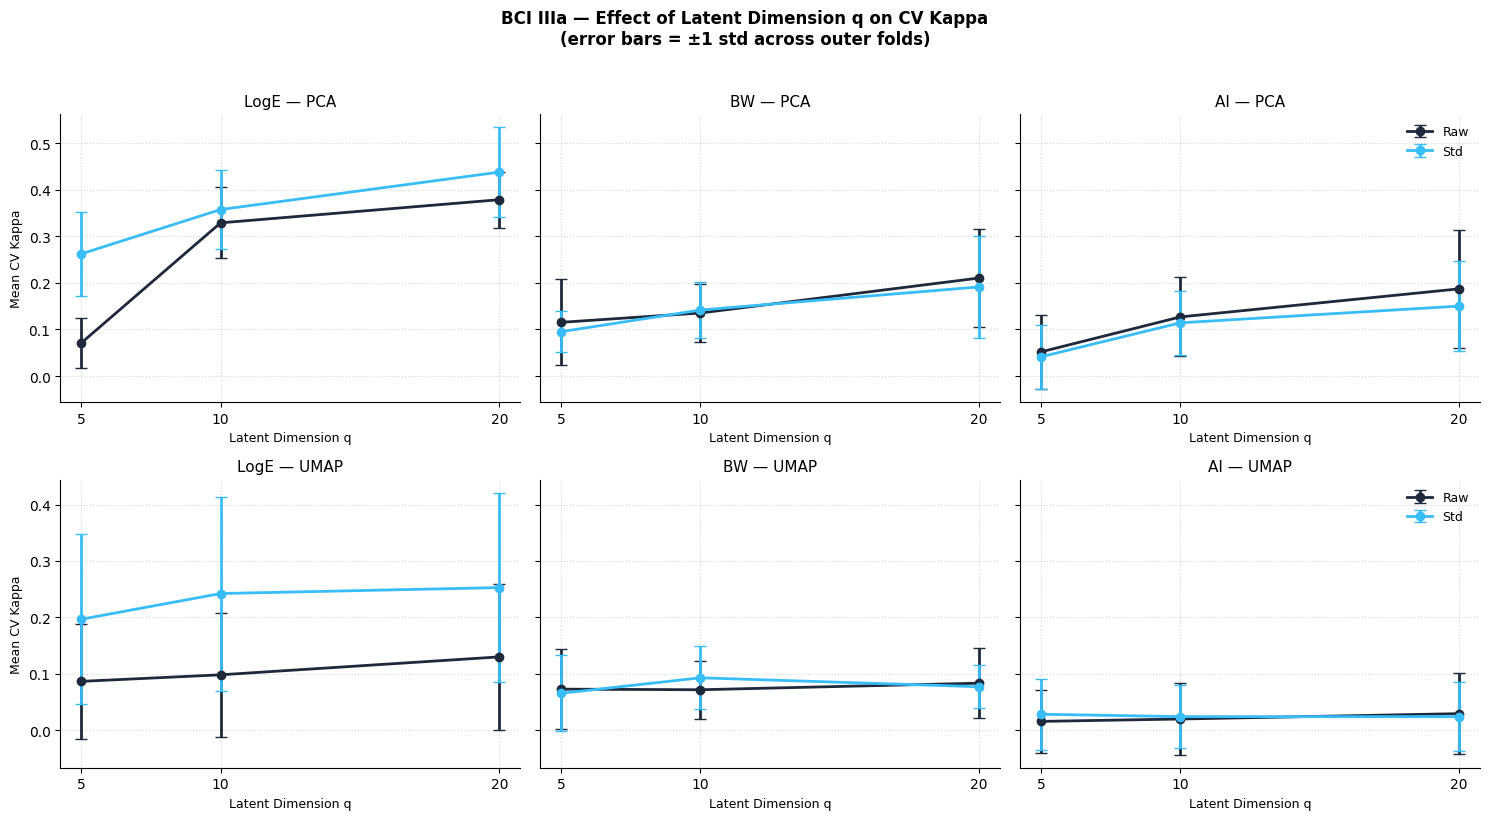

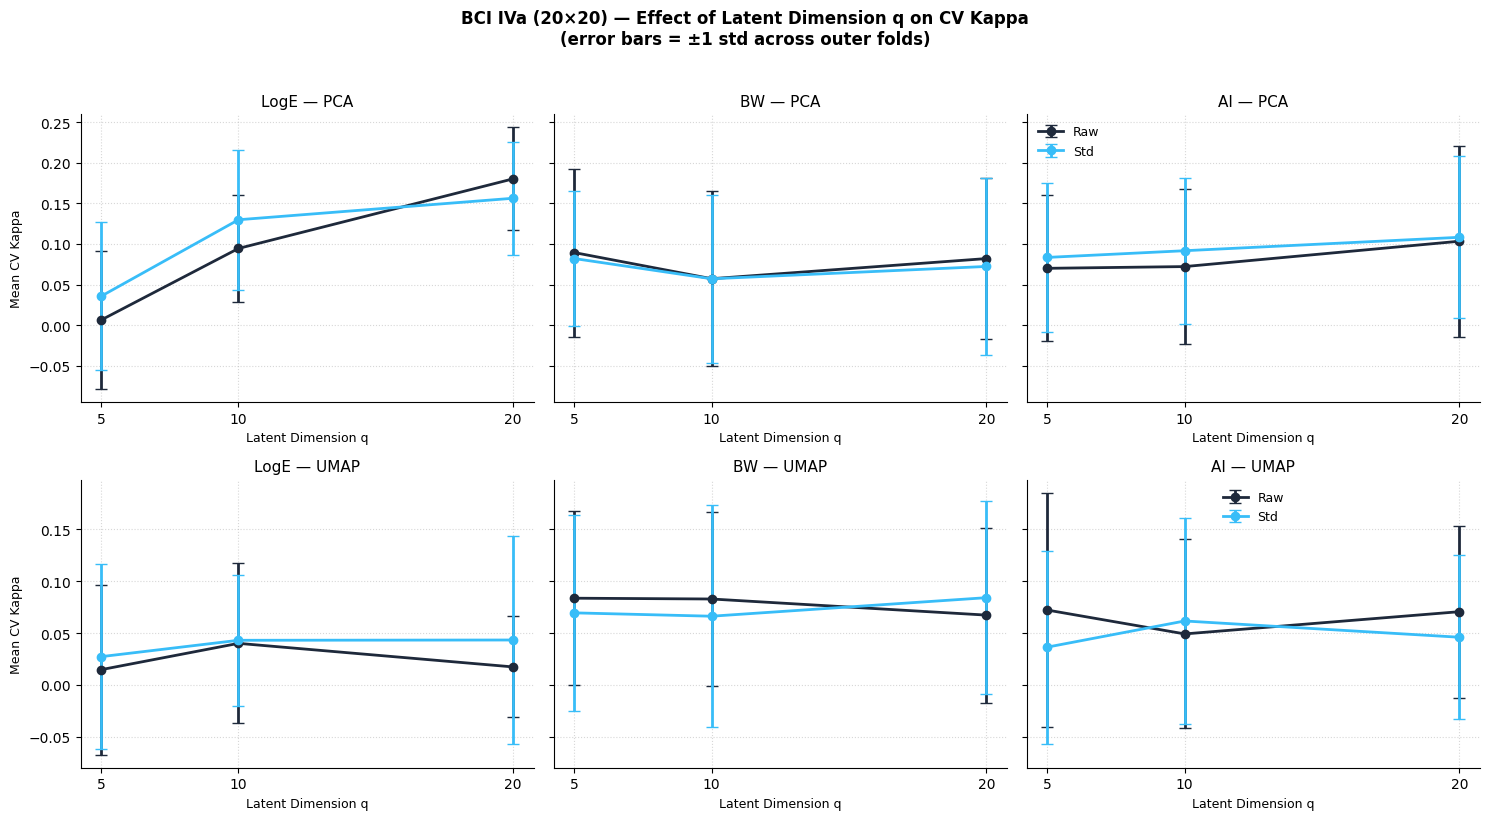

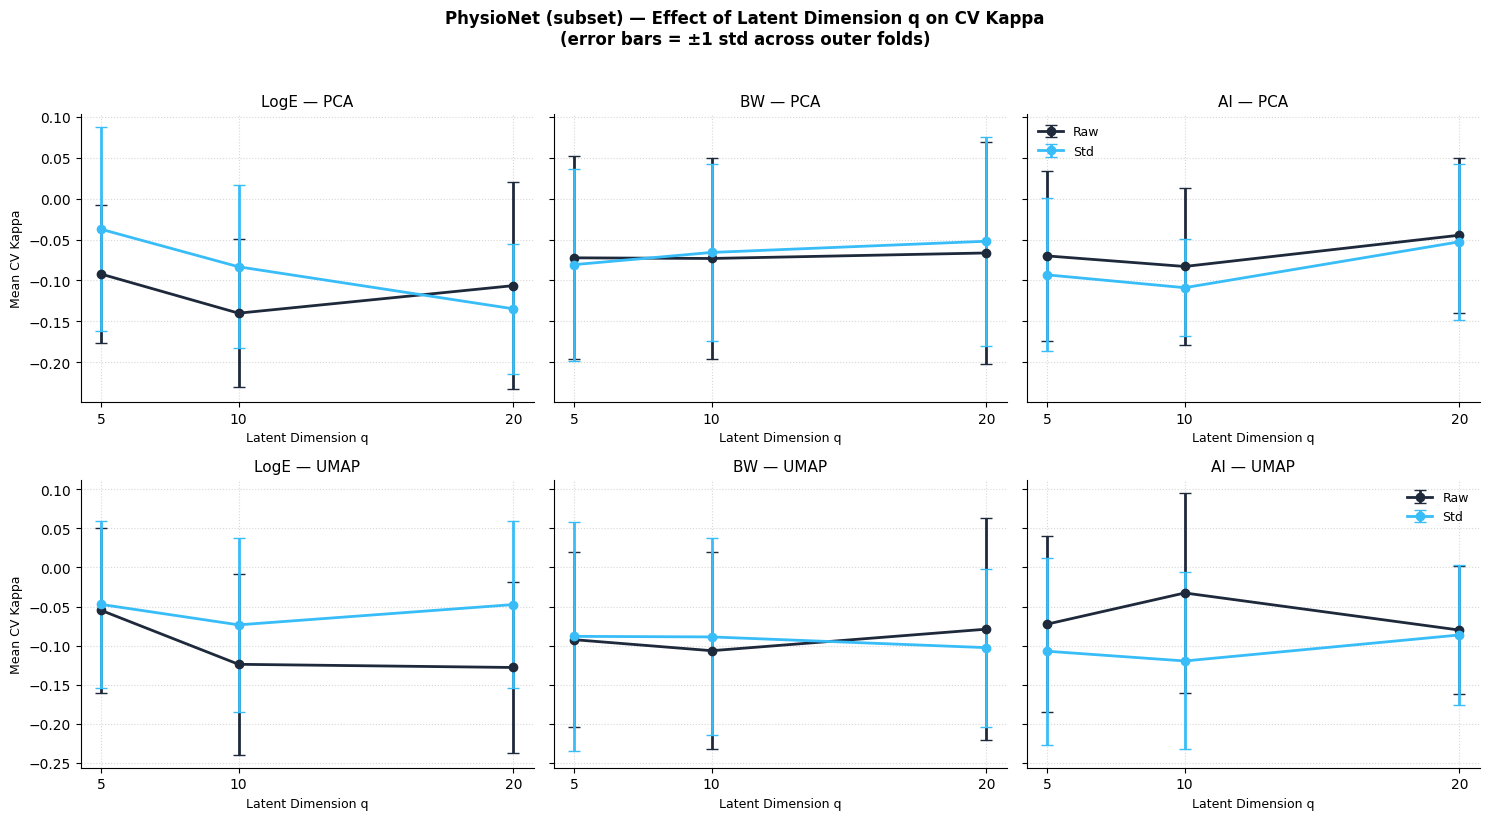

In [ ]:
# ── Run for each dataset ──────────────────────────────────────

plot_q_comparison(
    results_dict    = {'LogE': results_3a_loge,
                       'BW':   results_3a_bw,
                       'AI':   results_3a_ai},
    pipeline_configs = pipeline_configs,
    dataset_name    = "BCI IIIa",
    metric_key      = 'kappa'
)

plot_q_comparison(
    results_dict    = {'LogE': results_4a_loge,
                       'BW':   results_4a_bw,
                       'AI':   results_4a_ai},
    pipeline_configs = pipeline_configs_4a,
    dataset_name    = "BCI IVa (20×20)",
    metric_key      = 'kappa'
)

plot_q_comparison(
    results_dict    = {'LogE': results_phys_loge,
                       'BW':   results_phys_bw,
                       'AI':   results_phys_ai},
    pipeline_configs = pipeline_configs_phys,
    dataset_name    = "PhysioNet (subset)",
    metric_key      = 'kappa'
)